# TBD Phase 2 26L: Performance & Computing Models

## Introduction
In this lab, you will compare the performance and computing models of four popular data processing libraries/engines: **Polars, Pandas, DuckDB, and PySpark**.

You will explore:
- **Performance**: single-node processing speed, parallel execution, memory usage, and result materialization cost.
- **Scalability**: how performance changes with the number of local threads/cores and with Spark executors on a cluster.
- **Physical layout**: how file format, Parquet layout, row groups, sorting, partitioning, and pruning affect IO.
- **Computing models**: in-memory vs. out-of-core processing, SQL vs. DataFrame APIs, eager vs. lazy execution, and streaming execution vs. streaming output.

This notebook is an assignment template. It gives you a common structure and helper code, but you must design your own dataset variant, queries, benchmark implementation, and analysis.


## Submission identity

Before starting the assignment, copy this notebook into your fork of the workshop repository and work on that copy.

Fill in the first code cell with:

- your group number,
- a link to this notebook in your forked GitHub repository,
- names or IDs of group members if required by the instructor.

The submitted notebook should be reachable from your fork. Do not submit a notebook that only exists locally.

In [1]:
GROUP_ID = 2
NOTEBOOK_URL = "https://github.com/k-miel/tbd-workshop-1/blob/master/notebooks/tbd_phase_2_26L.ipynb"
GROUP_MEMBERS = ["Kacper Mielczarek / 321362", "Jakub Boruc / 321343", "Mateusz Piątek / 321364"]

assert GROUP_ID is not None, "Set GROUP_ID before running the notebook"
assert "<your-github-user-or-org>" not in NOTEBOOK_URL, "Set NOTEBOOK_URL to your forked repository notebook URL"

## Library/engine capabilities

Use this table as a reference when interpreting your results.

| Library/engine | Query optimizer | Distributed | Arrow-backed | Out-of-core | Parallel local execution | Main APIs |
|---|---|---|---|---|---|---|
| **Pandas 3.0** | no | no | default IO returns NumPy-backed data; `dtype_backend="pyarrow"` returns PyArrow-backed nullable dtypes | no | limited | DataFrame, `pd.col` for selected expression-style usage |
| **Polars** | yes | single-node locally; distributed engine is available in Polars Cloud and is outside this local benchmark | yes | yes | yes | DataFrame, lazy expressions, SQL subset |
| **DuckDB** | yes | no | yes | yes | yes | SQL, relational API |
| **PySpark** | yes | yes | yes, for selected IO/UDF paths | yes | yes | SQL, DataFrame |

The goal is not to prove that one library is always best. The goal is to identify which library/engine is appropriate for a given data size, query shape, memory limit, physical layout, and deployment model.

Use pandas 3.0 in this lab. Two pandas 3.0 behaviours matter for the benchmark: string columns are no longer inferred as generic `object` dtype by default, and Copy-on-Write is the only mutation model. In addition, compare two Pandas Parquet-reading variants where possible:

- default Pandas/NumPy-backed DataFrame: `pd.read_parquet(path)`,
- PyArrow-backed DataFrame: `pd.read_parquet(path, engine="pyarrow", dtype_backend="pyarrow")`.

Record the pandas version and dtypes in your report.


## Prerequisites

Install the required libraries in your notebook environment. If the course image already contains them, this command should be quick. Pandas 3.0 requires Python 3.11 or newer.

Use current Polars API in new code. In particular, use `collect(engine="streaming")` for streaming execution and use sink methods when you want to write streaming output to disk.

For Pandas, benchmark both the default backend and the PyArrow dtype backend for Parquet reads. The PyArrow-backed variant is especially relevant for string-heavy datasets.


In [2]:
# Dependencies are already installed in this environment (see versions printed in the next cell).
# Run this ONCE in a fresh environment to install everything. It is commented out so a full
# notebook re-run (e.g. `jupyter nbconvert --execute`) does not trigger a slow network reinstall.
# %pip install -U "pandas>=3.0,<3.1" polars duckdb pyspark faker deltalake memory_profiler pyarrow psutil matplotlib seaborn
print("Dependencies assumed installed; versions are verified in the next cell.")

Dependencies assumed installed; versions are verified in the next cell.


In [3]:
import gc
import os
import time
import json
import platform
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import polars as pl
import duckdb
import psutil
from faker import Faker
from memory_profiler import memory_usage
from pyspark.sql import SparkSession

print("Python:", platform.python_version())
if tuple(map(int, platform.python_version_tuple()[:2])) < (3, 11):
    raise RuntimeError("This notebook requires Python 3.11+ because it uses pandas 3.0.")
print("Polars:", pl.__version__)
print("Pandas:", pd.__version__)
if tuple(map(int, pd.__version__.split(".")[:2])) < (3, 0):
    raise RuntimeError("Install pandas 3.0+ before running the benchmark.")
print("DuckDB:", duckdb.__version__)
print("CPU logical cores:", psutil.cpu_count(logical=True))
print("RAM GiB:", round(psutil.virtual_memory().total / 2**30, 2))


Python: 3.12.10
Polars: 1.41.2
Pandas: 3.0.3
DuckDB: 1.5.3
CPU logical cores: 16
RAM GiB: 31.93


## Part 1: Data generation with group variants

Each group works with one assigned synthetic data profile. Use your group number to select the variant card below.

Your dataset does not need to match other groups exactly, but it must satisfy the common schema and benchmarking requirements described in this notebook.

Every group must document:
- dataset profile,
- main benchmark row count, plus any additional stress-test row counts if used,
- physical layout and file format choices,
- library versions,
- query intent,
- benchmark results,
- conclusions.

You may use the helper functions below, but you must adapt the dataset to your assigned variant.


## Variant cards for 16 groups

Choose or assign one variant per group.

| Group | Data profile | Required data feature | Suggested query stress |
|---:|---|---|---|
| 1 | Social media posts | tags or hashtags | explode/list handling, top-k |
| 2 | E-commerce orders | products and order values | join, category aggregation |
| 3 | IoT telemetry | device time series | time filters, rolling/window logic |
| 4 | Application logs | status codes and endpoints | selective filters, string columns |
| 5 | Advertising clicks | campaign skew | CTR, skewed group-by, join |
| 6 | Game events | player sessions | high-cardinality group-by |
| 7 | Streaming platform events | watch duration | device/country aggregation |
| 8 | Public transport events | route delays | time and location aggregation |
| 9 | Banking-like transactions | risk/fraud flags | selective filters, top-k, sorting |
| 10 | Web analytics | referrers and pages | funnel-like aggregation |
| 11 | Delivery/logistics events | late status updates | late events, time windows |
| 12 | Education platform activity | courses and students | joins and progress metrics |
| 13 | Weather measurements | missing values | resampling and null handling |
| 14 | Marketplace listings | prices and categories | quantiles, category statistics |
| 15 | Security events | rare alerts | selective filters and high skew |
| 16 | Support tickets | priority and SLA | time-to-resolution metrics |

You may rename columns and categories to fit the chosen profile. Keep enough common structure to run the same engine comparisons.

In [4]:
DOMAIN_CARDS = {
    1: {"name": "Social media posts", "feature": "tags", "stress": "explode/list handling and top-k"},
    2: {"name": "E-commerce orders", "feature": "products", "stress": "joins and category aggregation"},
    3: {"name": "IoT telemetry", "feature": "device time series", "stress": "time filters and rolling/window logic"},
    4: {"name": "Application logs", "feature": "status codes", "stress": "selective filters and string columns"},
    5: {"name": "Advertising clicks", "feature": "campaign skew", "stress": "CTR, skewed group-by, and joins"},
    6: {"name": "Game events", "feature": "player sessions", "stress": "high-cardinality group-by"},
    7: {"name": "Streaming platform events", "feature": "watch duration", "stress": "device/country aggregation"},
    8: {"name": "Public transport events", "feature": "route delays", "stress": "time and location aggregation"},
    9: {"name": "Banking-like transactions", "feature": "risk flags", "stress": "selective filters, top-k, and sorting"},
    10: {"name": "Web analytics", "feature": "referrers", "stress": "funnel-like aggregation"},
    11: {"name": "Delivery/logistics events", "feature": "late status updates", "stress": "late events and time windows"},
    12: {"name": "Education platform activity", "feature": "courses", "stress": "joins and progress metrics"},
    13: {"name": "Weather measurements", "feature": "missing values", "stress": "resampling and null handling"},
    14: {"name": "Marketplace listings", "feature": "prices", "stress": "quantiles and category statistics"},
    15: {"name": "Security events", "feature": "rare alerts", "stress": "selective filters and high skew"},
    16: {"name": "Support tickets", "feature": "priority and SLA", "stress": "time-to-resolution metrics"},
}

assert 1 <= GROUP_ID <= 16, "GROUP_ID must be between 1 and 16"
CARD = DOMAIN_CARDS[GROUP_ID]
CARD

{'name': 'E-commerce orders',
 'feature': 'products',
 'stress': 'joins and category aggregation'}

## Dataset requirements

Your generated dataset must contain at least:

- one timestamp column,
- one high-cardinality identifier, such as user, device, session, order, ticket, or transaction id,
- at least two categorical columns,
- at least two numeric metric columns,
- one feature specific to your variant card,
- enough rows to make local benchmark differences visible,
- a Parquet output file or directory.

Recommended starting sizes:

| Scale | Rows | Use case |
|---|---:|---|
| debug | 200,000 | Validate code quickly |
| small | 2,000,000 | Local development and first benchmark |
| medium | 10,000,000 to 20,000,000 | Main benchmark |
| large | 50,000,000+ | Optional stress test |

Use `debug` only while developing. The rendered notebook should report one main benchmark size (`N_ROWS`). If you run additional sizes, put those results in a separate stress-test table and do not mix them with the main benchmark table.

It is acceptable for different groups to generate different random data. Choose one main dataset size for the benchmark and record it as `N_ROWS`. You may use smaller debug data while developing and optional larger data for stress tests, but those extra sizes should be reported separately.

In [5]:
# Main dataset scale for the final benchmark.
# N_ROWS is the main row count reported for this notebook. Extra row counts are optional stress tests.
# Dataset configuration
SCALE = "medium"  # main benchmark = 10M rows (see "medium" in the recommended-sizes table)
SCALE_ROWS = {
    "debug": 200_000,
    "small": 2_000_000,
    "medium": 10_000_000,
    "large": 50_000_000,
}

N_ROWS = SCALE_ROWS[SCALE]
OUTPUT_DIR = Path("../data/phase2_26L") / f"group_{GROUP_ID:02d}"
EVENTS_PATH = OUTPUT_DIR / "events.parquet"
PARTITIONED_EVENTS_DIR = OUTPUT_DIR / "events_partitioned"
OPTIMIZED_EVENTS_PATH = OUTPUT_DIR / "events_optimized.parquet"
DIMENSION_PATH = OUTPUT_DIR / "dimension.parquet"
MANIFEST_PATH = OUTPUT_DIR / "manifest.json"

# Required negative baseline paths for the file-format/layout task. Do not commit these generated files.
CSV_EVENTS_PATH = OUTPUT_DIR / "events.csv"
JSON_EVENTS_PATH = OUTPUT_DIR / "events.jsonl"

# Leave SEED as None if you want independent data on each generation.
# If you need to reproduce exactly the same dataset later, set SEED to the value stored in the manifest.
SEED = 36742836879709687692425979607100424197  # pinned to the dataset used for the Dataproc run (reproducible)
RUN_SEED = int(np.random.SeedSequence().entropy) if SEED is None else int(SEED)
rng = np.random.default_rng(RUN_SEED)
fake = Faker()

print("Group:", GROUP_ID, CARD)
print("Rows:", N_ROWS)
print("Run seed recorded in manifest:", RUN_SEED)
print("Output directory:", OUTPUT_DIR)


Group: 2 {'name': 'E-commerce orders', 'feature': 'products', 'stress': 'joins and category aggregation'}
Rows: 10000000
Run seed recorded in manifest: 36742836879709687692425979607100424197
Output directory: ..\data\phase2_26L\group_02


## Generator template

The helper below creates a common base event table. You should extend it for your variant.

Do not spend most of the assignment writing a perfect data generator. The generator only needs to create data that is large enough and structurally interesting enough for your benchmark questions.

In [6]:
# Group 2 variant: E-commerce orders.
# Required feature: products + order values. Query stress: joins + category aggregation.
#
# Schema produced (events table):
#   order_id          int64    high-cardinality unique id (1..N_ROWS)
#   customer_id       int64    high-cardinality, SKEWED (hot 2% of customers get 50% of orders)
#   order_ts          datetime timestamp column
#   order_date        date     date derived from order_ts (used for partitioning + range filters)
#   product_id        int64    FK into the products dimension (1..N_PRODUCTS), SKEWED
#   product_category  str      8 categories, derived deterministically from product_id
#   country           str      buyer country (categorical)
#   device            str      mobile/desktop/tablet (categorical)
#   payment_method    str      card/paypal/transfer/cod, ~3% NULLs (null handling)
#   order_status      str      completed/returned/cancelled (skewed)
#   order_value       float64  monetary line total in EUR (lognormal -> long tail)
#   quantity          int16    units per order (1..10)
#
# Dimension table (products): product_id -> brand, supplier_country, unit_price.
# brand / supplier_country live ONLY in the dimension, so the "category aggregation"
# query (Q1) genuinely needs the join.

N_PRODUCTS = 50_000
PRODUCT_CATEGORIES = np.array(
    ["electronics", "fashion", "home", "beauty", "sports", "books", "toys", "grocery"]
)
SUPPLIER_COUNTRIES = np.array(["PL", "DE", "CN", "US", "VN", "TR"])


def skewed_ids(rng, n, max_id, hot_fraction=0.02, hot_probability=0.50):
    hot_count = max(1, int(max_id * hot_fraction))
    ids = rng.integers(hot_count + 1, max_id + 1, size=n)
    hot_mask = rng.random(n) < hot_probability
    ids[hot_mask] = rng.integers(1, hot_count + 1, size=hot_mask.sum())
    return ids


def generate_base_events(n, rng):
    start = np.datetime64("2026-01-01T00:00:00", "s")
    end = np.datetime64("2026-04-01T00:00:00", "s")
    seconds = int((end - start) / np.timedelta64(1, "s"))
    event_ts = (start + rng.integers(0, seconds, size=n).astype("timedelta64[s]")).astype("datetime64[us]")

    # Vectorised base columns. No nested/list columns (keeps the CSV baseline flat for Task 2.5).
    df = pl.DataFrame(
        {
            "event_id": np.arange(1, n + 1, dtype=np.int64),
            "entity_id": skewed_ids(rng, n, max_id=200_000),
            "event_ts": event_ts,
            "country": rng.choice(["PL", "DE", "FR", "UK", "US", "IN", "BR"], size=n),
            "device": rng.choice(["mobile", "desktop", "tablet"], size=n, p=[0.65, 0.25, 0.10]),
            "metric_1": rng.lognormal(mean=4.0, sigma=1.0, size=n).round(2),
            "metric_2": rng.integers(0, 10_000, size=n),
        }
    )
    return df.with_columns(pl.col("event_ts").dt.date().alias("event_date"))


def customize_for_variant(df, card, rng):
    # Adapt the generic base table to the E-commerce orders variant.
    n = df.height

    product_id = skewed_ids(rng, n, max_id=N_PRODUCTS)
    # product_category is a deterministic function of product_id (same mapping used in the
    # dimension), so the denormalised events.product_category stays consistent with the join key.
    product_category = PRODUCT_CATEGORIES[product_id % len(PRODUCT_CATEGORIES)]

    payment = rng.choice(
        ["card", "paypal", "transfer", "cod"], size=n, p=[0.55, 0.25, 0.15, 0.05]
    ).astype(object)
    payment[rng.random(n) < 0.03] = None  # ~3% missing payment method -> null handling

    order_status = rng.choice(
        ["completed", "returned", "cancelled"], size=n, p=[0.85, 0.10, 0.05]
    )
    quantity = (df.get_column("metric_2").to_numpy() % 10 + 1).astype(np.int16)

    return pl.DataFrame(
        {
            "order_id": df.get_column("event_id").to_numpy(),
            "customer_id": df.get_column("entity_id").to_numpy(),
            "order_ts": df.get_column("event_ts"),
            "order_date": df.get_column("event_date"),
            "product_id": product_id,
            "product_category": product_category,
            "country": df.get_column("country"),
            "device": df.get_column("device"),
            "payment_method": payment,
            "order_status": order_status,
            "order_value": df.get_column("metric_1"),  # EUR line total (lognormal long tail)
            "quantity": quantity,
        }
    )


def generate_dimension_table(card, rng):
    # Products dimension. brand / supplier_country / unit_price exist ONLY here, so the
    # category-aggregation query must join events -> products to reach them.
    product_id = np.arange(1, N_PRODUCTS + 1, dtype=np.int64)
    brand = np.array([f"brand_{b:03d}" for b in (product_id % 200)])
    supplier_country = rng.choice(SUPPLIER_COUNTRIES, size=N_PRODUCTS)
    unit_price = rng.lognormal(mean=3.0, sigma=0.8, size=N_PRODUCTS).round(2)
    return pl.DataFrame(
        {
            "product_id": product_id,
            "brand": brand,
            "supplier_country": supplier_country,
            "unit_price": unit_price,
        }
    )

In [7]:
# Generate and save the dataset. Generated data lives under data/phase2_26L/ and is gitignored.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

gen_t0 = time.perf_counter()
base_events = generate_base_events(N_ROWS, rng)
events = customize_for_variant(base_events, CARD, rng)
dimension = generate_dimension_table(CARD, rng)
del base_events
gc.collect()
print(f"Generated {events.height:,} rows in {time.perf_counter() - gen_t0:.1f}s")

# Default layout: single Parquet file, rows in random (insertion) order.
events.write_parquet(EVENTS_PATH, compression="zstd")
dimension.write_parquet(DIMENSION_PATH, compression="zstd")

# Partitioned layout (Hive-style by order_date) for predicate-pushdown / partition-pruning experiments.
events.write_parquet(PARTITIONED_EVENTS_DIR, partition_by="order_date", compression="zstd")

# Optimized layout for the Q3 access pattern (date-range + product_category filter, daily aggregation).
# Sorting by (order_date, product_category) clusters those values so each Parquet row group covers a
# narrow date/category range -> min/max statistics let readers skip most row groups for a selective
# filter. A smaller row_group_size makes pruning finer-grained.
events.sort(["order_date", "product_category"]).write_parquet(
    OPTIMIZED_EVENTS_PATH,
    compression="zstd",
    row_group_size=100_000,
)

manifest = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "group_id": GROUP_ID,
    "variant": CARD,
    "scale": SCALE,
    "rows": int(events.height),
    "run_seed": RUN_SEED,
    "paths": {
        "events": str(EVENTS_PATH),
        "events_partitioned": str(PARTITIONED_EVENTS_DIR),
        "events_optimized": str(OPTIMIZED_EVENTS_PATH),
        "dimension": str(DIMENSION_PATH),
    },
    "environment": {
        "python": platform.python_version(),
        "polars": pl.__version__,
        "pandas": pd.__version__,
        "duckdb": duckdb.__version__,
        "cpu_logical_cores": psutil.cpu_count(logical=True),
        "ram_gib": round(psutil.virtual_memory().total / 2**30, 2),
    },
}
MANIFEST_PATH.write_text(json.dumps(manifest, indent=2), encoding="utf-8")

print(json.dumps(manifest, indent=2))


Generated 10,000,000 rows in 9.0s


{
  "created_at_utc": "2026-06-15T21:32:15.330850+00:00",
  "group_id": 2,
  "variant": {
    "name": "E-commerce orders",
    "feature": "products",
    "stress": "joins and category aggregation"
  },
  "scale": "medium",
  "rows": 10000000,
  "run_seed": 36742836879709687692425979607100424197,
  "paths": {
    "events": "..\\data\\phase2_26L\\group_02\\events.parquet",
    "events_partitioned": "..\\data\\phase2_26L\\group_02\\events_partitioned",
    "events_optimized": "..\\data\\phase2_26L\\group_02\\events_optimized.parquet",
    "dimension": "..\\data\\phase2_26L\\group_02\\dimension.parquet"
  },
  "environment": {
    "python": "3.12.10",
    "polars": "1.41.2",
    "pandas": "3.0.3",
    "duckdb": "1.5.3",
    "cpu_logical_cores": 16,
    "ram_gib": 31.93
  }
}


## Dataset sanity checks

Before benchmarking, inspect your schema and basic statistics. Your report should briefly explain why your dataset is suitable for the queries you chose.

In [8]:
# Dataset sanity checks: schema, row count, nulls, category distributions, on-disk sizes.
print("EVENTS schema:")
print(events.schema)
print(f"\nRows: {events.height:,}  |  Columns: {events.width}")

# Null counts (only payment_method should have ~3% nulls).
print("\nNull counts per column:")
print(events.null_count())

# High-cardinality identifiers.
print(
    f"\nDistinct customer_id: {events['customer_id'].n_unique():,}"
    f"  |  distinct product_id: {events['product_id'].n_unique():,}"
    f"  |  distinct order_id: {events['order_id'].n_unique():,}"
)

# Categorical distributions.
for col in ["product_category", "order_status", "country", "device"]:
    print(f"\n{col} distribution:")
    print(events[col].value_counts(sort=True))

# Numeric metric summary + skew evidence (top customers' share of orders).
print("\norder_value / quantity summary:")
print(events.select(["order_value", "quantity"]).describe())

top_share = (
    events.group_by("customer_id").len()
    .sort("len", descending=True)
    .head(int(0.02 * events["customer_id"].n_unique()))["len"].sum()
)
print(f"\nSkew check: hottest ~2% of customers account for {100 * top_share / events.height:.1f}% of all orders")

# Dimension preview + on-disk sizes.
print("\nDIMENSION (products) head:")
print(dimension.head())


def _size_mb(p):
    p = Path(p)
    if p.is_dir():
        return sum(f.stat().st_size for f in p.rglob("*") if f.is_file()) / 2**20
    return p.stat().st_size / 2**20 if p.exists() else float("nan")

print("\nOn-disk sizes (MiB):")
for label, path in [
    ("events.parquet (default)", EVENTS_PATH),
    ("events_optimized.parquet", OPTIMIZED_EVENTS_PATH),
    ("events_partitioned/", PARTITIONED_EVENTS_DIR),
    ("dimension.parquet", DIMENSION_PATH),
]:
    print(f"  {label:30s} {_size_mb(path):8.1f}")


EVENTS schema:
Schema({'order_id': Int64, 'customer_id': Int64, 'order_ts': Datetime(time_unit='us', time_zone=None), 'order_date': Date, 'product_id': Int64, 'product_category': String, 'country': String, 'device': String, 'payment_method': String, 'order_status': String, 'order_value': Float64, 'quantity': Int16})

Rows: 10,000,000  |  Columns: 12

Null counts per column:
shape: (1, 12)
┌──────────┬────────────┬──────────┬────────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ order_id ┆ customer_i ┆ order_ts ┆ order_date ┆ … ┆ payment_m ┆ order_sta ┆ order_val ┆ quantity │
│ ---      ┆ d          ┆ ---      ┆ ---        ┆   ┆ ethod     ┆ tus       ┆ ue        ┆ ---      │
│ u32      ┆ ---        ┆ u32      ┆ u32        ┆   ┆ ---       ┆ ---       ┆ ---       ┆ u32      │
│          ┆ u32        ┆          ┆            ┆   ┆ u32       ┆ u32       ┆ u32       ┆          │
╞══════════╪════════════╪══════════╪════════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 

shape: (8, 2)
┌──────────────────┬─────────┐
│ product_category ┆ count   │
│ ---              ┆ ---     │
│ str              ┆ u32     │
╞══════════════════╪═════════╡
│ sports           ┆ 1251975 │
│ fashion          ┆ 1250902 │
│ beauty           ┆ 1250577 │
│ electronics      ┆ 1250403 │
│ books            ┆ 1249265 │
│ home             ┆ 1249095 │
│ toys             ┆ 1249009 │
│ grocery          ┆ 1248774 │
└──────────────────┴─────────┘

order_status distribution:
shape: (3, 2)
┌──────────────┬─────────┐
│ order_status ┆ count   │
│ ---          ┆ ---     │
│ str          ┆ u32     │
╞══════════════╪═════════╡
│ completed    ┆ 8500694 │
│ returned     ┆ 999620  │
│ cancelled    ┆ 499686  │
└──────────────┴─────────┘

country distribution:


shape: (7, 2)
┌─────────┬─────────┐
│ country ┆ count   │
│ ---     ┆ ---     │
│ str     ┆ u32     │
╞═════════╪═════════╡
│ FR      ┆ 1431612 │
│ BR      ┆ 1428849 │
│ PL      ┆ 1428730 │
│ IN      ┆ 1428460 │
│ DE      ┆ 1427591 │
│ UK      ┆ 1427589 │
│ US      ┆ 1427169 │
└─────────┴─────────┘

device distribution:
shape: (3, 2)
┌─────────┬─────────┐
│ device  ┆ count   │
│ ---     ┆ ---     │
│ str     ┆ u32     │
╞═════════╪═════════╡
│ mobile  ┆ 6498158 │
│ desktop ┆ 2501033 │
│ tablet  ┆ 1000809 │
└─────────┴─────────┘

order_value / quantity summary:
shape: (9, 3)
┌────────────┬─────────────┬───────────┐
│ statistic  ┆ order_value ┆ quantity  │
│ ---        ┆ ---         ┆ ---       │
│ str        ┆ f64         ┆ f64       │
╞════════════╪═════════════╪═══════════╡
│ count      ┆ 1e7         ┆ 1e7       │
│ null_count ┆ 0.0         ┆ 0.0       │
│ mean       ┆ 90.030877   ┆ 5.5004487 │
│ std        ┆ 117.780094  ┆ 2.87275   │
│ min        ┆ 0.33        ┆ 1.0       │
│ 25%    


Skew check: hottest ~2% of customers account for 50.0% of all orders

DIMENSION (products) head:
shape: (5, 4)
┌────────────┬───────────┬──────────────────┬────────────┐
│ product_id ┆ brand     ┆ supplier_country ┆ unit_price │
│ ---        ┆ ---       ┆ ---              ┆ ---        │
│ i64        ┆ str       ┆ str              ┆ f64        │
╞════════════╪═══════════╪══════════════════╪════════════╡
│ 1          ┆ brand_001 ┆ VN               ┆ 86.61      │
│ 2          ┆ brand_002 ┆ DE               ┆ 10.66      │
│ 3          ┆ brand_003 ┆ PL               ┆ 63.21      │
│ 4          ┆ brand_004 ┆ VN               ┆ 10.55      │
│ 5          ┆ brand_005 ┆ CN               ┆ 20.96      │
└────────────┴───────────┴──────────────────┴────────────┘

On-disk sizes (MiB):
  events.parquet (default)          173.7
  events_optimized.parquet          179.7
  events_partitioned/               161.0
  dimension.parquet                   0.2


## Part 2: Measuring performance

You must use one consistent benchmark protocol for all libraries/engines.

Minimum requirements:

1. Run every benchmark at least three times. Five repetitions are recommended.
2. Run `gc.collect()` before each measured repetition to reduce noise from previous Python allocations.
3. Report median runtime, not only one measurement.
4. Record peak memory where possible.
5. Check that results are logically equivalent across libraries/engines.
6. Store your results in a table.
7. Describe any library/engine-specific settings, such as Pandas dtype backend, thread count, Spark local mode, or DuckDB threads.

**Important for memory benchmarks**: notebook kernels keep allocations and library state between cells. Peak-RSS comparisons are often misleading when all variants run in the same process. For Task 3.1 and any memory-sensitive comparison, prefer running each variant in a fresh process or a small standalone script. If you cannot do that, clearly state this limitation.

You may use the helper shape below, but you need to implement the actual benchmark functions.


In [9]:
import statistics

BENCHMARK_COLUMNS = [
    "library_engine",
    "mode",
    "query_name",
    "data_format",
    "layout",
    "rows",
    "median_time_s",
    "peak_memory_mb",
    "input_size_mb",
    "result_check",
    "notes",
]

benchmark_results = []

# Benchmark protocol (applied uniformly to every library/engine):
#   * REPEATS timed runs, gc.collect() before each, report the MEDIAN runtime.
#   * Peak memory measured once via memory_profiler as the increase in process RSS during the call.
#       - This is the Python-process RSS, so it is only meaningful for in-process engines
#         (Pandas / Polars / DuckDB). For PySpark the work happens in a separate JVM, so we set
#         measure_memory=False and record that in the notes (documented limitation).
#       - Even for in-process engines, a shared notebook kernel keeps allocations/caches between
#         cells, so peak-RSS comparisons are indicative, not exact. Task 3.1 discusses this further.
#   * result_check stores a small canonical signature so we can confirm logical equivalence across
#     engines (exact integer counts + revenue rounded to the nearest EUR; float summation order can
#     differ slightly between engines, so the revenue figure is rounded).

REPEATS = 3  # minimum required is 3; 5 is recommended. 3 keeps the full 10M end-to-end run tractable.


def file_size_mb(path):
    p = Path(path)
    if p.is_dir():
        return sum(f.stat().st_size for f in p.rglob("*") if f.is_file()) / 2**20
    return p.stat().st_size / 2**20 if p.exists() else float("nan")


def _time_repeats(fn, repeats=REPEATS):
    """Run fn `repeats` times (gc before each) and return (median_seconds, last_result)."""
    times, last = [], None
    for _ in range(repeats):
        gc.collect()
        t0 = time.perf_counter()
        last = fn()
        times.append(time.perf_counter() - t0)
    return statistics.median(times), last


def _peak_memory_mb(fn):
    """Peak increase in process RSS (MiB) during one call of fn."""
    proc = psutil.Process()
    gc.collect()
    base = proc.memory_info().rss / 2**20
    peak = memory_usage((fn,), max_usage=True, interval=0.05)
    return round(float(peak) - base, 1)


def benchmark_query(
    library_engine,
    mode,
    query_name,
    fn,
    *,
    data_format="parquet",
    layout="default",
    rows=None,
    input_size_mb=None,
    measure_memory=True,
    notes="",
):
    """Time + (optionally) memory-profile a query callable and append one BENCHMARK_COLUMNS row."""
    median_t, result = _time_repeats(fn)
    peak = _peak_memory_mb(fn) if measure_memory else None
    row = {col: None for col in BENCHMARK_COLUMNS}
    row.update(
        library_engine=library_engine,
        mode=mode,
        query_name=query_name,
        data_format=data_format,
        layout=layout,
        rows=rows if rows is not None else N_ROWS,
        median_time_s=round(median_t, 4),
        peak_memory_mb=peak,
        input_size_mb=round(input_size_mb, 2) if input_size_mb is not None else None,
        result_check=result,
        notes=notes,
    )
    benchmark_results.append(row)
    print(f"  {library_engine:16s} {mode:18s} {query_name:4s} "
          f"median={median_t:7.3f}s  peak_mem={str(peak)+' MiB' if peak is not None else 'n/a':>12}  check={result}")
    return row


def results_df(rows=None):
    return pd.DataFrame(rows if rows is not None else benchmark_results, columns=BENCHMARK_COLUMNS)


# ---- Canonical result signatures (logical-equivalence checks across engines) ------------------
# Each takes a small pandas DataFrame (the query result) and returns a compact string.
def check_q1(pdf):
    return f"groups={len(pdf)}|orders={int(pdf['orders'].sum())}|rev={int(round(pdf['revenue'].sum()))}"


def check_q2(pdf):
    top = pdf.sort_values("revenue", ascending=False)
    return (f"rows={len(top)}|top_customer={int(top.iloc[0]['customer_id'])}"
            f"|orders={int(top['orders'].sum())}|rev={int(round(top['revenue'].sum()))}")


def check_q3(pdf):
    return f"days={len(pdf)}|orders={int(pdf['orders'].sum())}|rev={int(round(pdf['revenue'].sum()))}"


## Part 3: Student tasks

### Task 1: Design three benchmark queries

Create three queries of your own choice. They must test different behavior.

Your queries should cover at least three of the following classes:

- selective filter plus aggregation,
- high-cardinality group-by,
- top-k or sorting,
- list/tag explode,
- join with a dimension table,
- window or rolling computation,
- query that produces a large output,
- query sensitive to partitioned vs. unpartitioned layout,
- query sensitive to column pruning, predicate pushdown, or row-group pruning.

For each query, write a short hypothesis before you run it:

- what does this query test?
- which library/engine do you expect to perform best?
- which library/engine may use the most memory?
- which physical layout should help, if any?


In [10]:
import datetime as dt
from IPython.display import Markdown, display

# ---- Shared query parameters -----------------------------------------------------------------
Q3_DATE_START = dt.date(2026, 2, 1)
Q3_DATE_END = dt.date(2026, 2, 14)   # inclusive 2-week window (~15% of the 90-day span)
Q3_CATEGORY = "electronics"
Q2_TOPK = 20


def to_posix(path):
    """Absolute POSIX path string, used for DuckDB/Spark file references on Windows."""
    return Path(path).resolve().as_posix()


# ---- Three benchmark queries (cover join, high-cardinality group-by, selective filter) -------
QUERY_SPECS = {
    "Q1": {
        "title": "Join + category aggregation (revenue by supplier country)",
        "classes": ["join with a dimension table", "category aggregation"],
        "intent": "Join 10M orders to the products dimension on product_id, then aggregate "
                  "revenue / order count / avg quantity per supplier_country. supplier_country "
                  "lives ONLY in the dimension, so the join is unavoidable.",
        "tests": "Large-to-small (10M x 50k) hash join then a tiny group-by. This is the "
                 "variant's required 'joins + category aggregation' stress.",
        "expect_fastest": "DuckDB and Polars-lazy (build a hash table on the 50k dimension, "
                          "stream the 10M side, project only needed columns).",
        "expect_most_memory": "Pandas default (NumPy) backend: it reads ALL columns of both "
                              "tables into memory and materialises the merged frame.",
        "layout_help": "Column pruning matters most; partition/sort layout does not help a "
                       "non-selective full-scan join.",
    },
    "Q2": {
        "title": "High-cardinality group-by + top-k (best customers)",
        "classes": ["high-cardinality group-by", "top-k / sorting"],
        "intent": "Filter to completed orders, aggregate revenue + order count per customer_id "
                  "(~200k distinct, skewed), sort by revenue and keep the top 20.",
        "tests": "Hash aggregation over a high-cardinality, skewed key followed by a partial sort. "
                 "Stresses the aggregation/sort machinery, not IO.",
        "expect_fastest": "Polars / DuckDB (parallel hash aggregation + top-k).",
        "expect_most_memory": "Pandas: the per-customer group table (~200k groups) plus the full "
                              "in-memory frame.",
        "layout_help": "Little: the query scans almost all rows. Mainly a compute benchmark.",
    },
    "Q3": {
        "title": "Selective filter + aggregation (daily electronics revenue, layout-sensitive)",
        "classes": ["selective filter plus aggregation",
                    "sensitive to predicate pushdown / row-group pruning"],
        "intent": f"Filter orders to {Q3_DATE_START}..{Q3_DATE_END} AND "
                  f"product_category='{Q3_CATEGORY}', aggregate daily revenue + order count.",
        "tests": "A highly selective predicate (~2 weeks x 1/8 categories ~ 2% of rows). The engine "
                 "that pushes the predicate/projection down and prunes row groups reads the least data. "
                 "Reused in Task 2.5 to compare physical layouts.",
        "expect_fastest": "DuckDB / Polars-lazy on the OPTIMIZED (sorted, small row-group) layout, "
                          "where row-group min/max stats skip most data.",
        "expect_most_memory": "CSV baseline (Task 2.5): no pushdown, must parse every byte.",
        "layout_help": "Strongly: sorting by (order_date, product_category) + small row_group_size "
                       "enables row-group pruning; partitioning by order_date enables partition pruning.",
    },
}

_md = ["## Query specifications and hypotheses\n"]
for qid, s in QUERY_SPECS.items():
    _md.append(
        f"### {qid} — {s['title']}\n"
        f"- **Classes:** {', '.join(s['classes'])}\n"
        f"- **Intent:** {s['intent']}\n"
        f"- **What it tests:** {s['tests']}\n"
        f"- **Expected fastest:** {s['expect_fastest']}\n"
        f"- **Expected most memory:** {s['expect_most_memory']}\n"
        f"- **Layout that should help:** {s['layout_help']}\n"
    )
display(Markdown("\n".join(_md)))


## Query specifications and hypotheses

### Q1 — Join + category aggregation (revenue by supplier country)
- **Classes:** join with a dimension table, category aggregation
- **Intent:** Join 10M orders to the products dimension on product_id, then aggregate revenue / order count / avg quantity per supplier_country. supplier_country lives ONLY in the dimension, so the join is unavoidable.
- **What it tests:** Large-to-small (10M x 50k) hash join then a tiny group-by. This is the variant's required 'joins + category aggregation' stress.
- **Expected fastest:** DuckDB and Polars-lazy (build a hash table on the 50k dimension, stream the 10M side, project only needed columns).
- **Expected most memory:** Pandas default (NumPy) backend: it reads ALL columns of both tables into memory and materialises the merged frame.
- **Layout that should help:** Column pruning matters most; partition/sort layout does not help a non-selective full-scan join.

### Q2 — High-cardinality group-by + top-k (best customers)
- **Classes:** high-cardinality group-by, top-k / sorting
- **Intent:** Filter to completed orders, aggregate revenue + order count per customer_id (~200k distinct, skewed), sort by revenue and keep the top 20.
- **What it tests:** Hash aggregation over a high-cardinality, skewed key followed by a partial sort. Stresses the aggregation/sort machinery, not IO.
- **Expected fastest:** Polars / DuckDB (parallel hash aggregation + top-k).
- **Expected most memory:** Pandas: the per-customer group table (~200k groups) plus the full in-memory frame.
- **Layout that should help:** Little: the query scans almost all rows. Mainly a compute benchmark.

### Q3 — Selective filter + aggregation (daily electronics revenue, layout-sensitive)
- **Classes:** selective filter plus aggregation, sensitive to predicate pushdown / row-group pruning
- **Intent:** Filter orders to 2026-02-01..2026-02-14 AND product_category='electronics', aggregate daily revenue + order count.
- **What it tests:** A highly selective predicate (~2 weeks x 1/8 categories ~ 2% of rows). The engine that pushes the predicate/projection down and prunes row groups reads the least data. Reused in Task 2.5 to compare physical layouts.
- **Expected fastest:** DuckDB / Polars-lazy on the OPTIMIZED (sorted, small row-group) layout, where row-group min/max stats skip most data.
- **Expected most memory:** CSV baseline (Task 2.5): no pushdown, must parse every byte.
- **Layout that should help:** Strongly: sorting by (order_date, product_category) + small row_group_size enables row-group pruning; partitioning by order_date enables partition pruning.


### Task 2: Benchmark local libraries/engines

Implement your three queries in:

- Pandas 3.0 with the default NumPy-backed output from `pd.read_parquet(path)`,
- Pandas 3.0 with `pd.read_parquet(path, engine="pyarrow", dtype_backend="pyarrow")`,
- Polars,
- DuckDB,
- PySpark local mode.

For Polars, benchmark at least:

- eager execution,
- lazy execution with default collection,
- lazy execution with streaming engine.

For PySpark, use local mode in this task. Dataproc is a separate task later in the notebook.


In [11]:
# PySpark local session. Created once here and reused by the local Spark benchmark.
# Local mode: a single JVM with `local[*]` worker threads (no cluster, no network shuffle service).
from pyspark.sql import functions as F


def build_local_spark(master="local[*]", app="TBDPhase2LocalBenchmark"):
    return (
        SparkSession.builder
        .appName(app)
        .master(master)
        .config("spark.driver.memory", "6g")
        .config("spark.sql.shuffle.partitions", "16")   # tuned down for a single machine
        .config("spark.sql.adaptive.enabled", "true")
        .config("spark.ui.showConsoleProgress", "false")
        .getOrCreate()
    )


spark = build_local_spark()
spark.sparkContext.setLogLevel("ERROR")
print("Spark version:", spark.version, "| master:", spark.sparkContext.master)
print("Default parallelism:", spark.sparkContext.defaultParallelism)


Spark version: 4.1.2 | master: local[*]
Default parallelism: 16


In [12]:
# Pandas 3.0 implementations of Q1-Q3, for BOTH read backends:
#   "numpy"   -> pd.read_parquet(path)                                  (NumPy-backed dtypes)
#   "pyarrow" -> pd.read_parquet(path, engine="pyarrow",
#                                dtype_backend="pyarrow")               (Arrow-backed nullable dtypes)
# Pandas has no query optimizer / projection pushdown: read_parquet loads every column, so these
# functions reflect the realistic "load the whole table, then process" Pandas pattern.

def pd_load(path, backend):
    if backend == "numpy":
        return pd.read_parquet(path)
    return pd.read_parquet(path, engine="pyarrow", dtype_backend="pyarrow")


def pandas_q1(backend):
    ev = pd_load(EVENTS_PATH, backend)
    dim = pd_load(DIMENSION_PATH, backend)
    merged = ev.merge(dim[["product_id", "supplier_country"]], on="product_id", how="inner")
    g = (merged.groupby("supplier_country", observed=True)
         .agg(revenue=("order_value", "sum"), orders=("order_id", "count"), avg_qty=("quantity", "mean"))
         .reset_index())
    return check_q1(g)


def pandas_q2(backend):
    ev = pd_load(EVENTS_PATH, backend)
    completed = ev[ev["order_status"] == "completed"]
    g = (completed.groupby("customer_id", observed=True)
         .agg(revenue=("order_value", "sum"), orders=("order_id", "count"))
         .reset_index())
    top = g.nlargest(Q2_TOPK, "revenue")
    return check_q2(top)


def pandas_q3(backend):
    ev = pd_load(EVENTS_PATH, backend)
    od = pd.to_datetime(ev["order_date"])
    mask = (od >= pd.Timestamp(Q3_DATE_START)) & (od <= pd.Timestamp(Q3_DATE_END)) & (
        ev["product_category"] == Q3_CATEGORY
    )
    sub = ev[mask].copy()
    sub["order_date"] = pd.to_datetime(sub["order_date"])
    g = (sub.groupby("order_date", observed=True)
         .agg(revenue=("order_value", "sum"), orders=("order_id", "count"))
         .reset_index())
    return check_q3(g)


# Report dtypes for both backends (Pandas 3.0: strings are no longer generic object dtype).
print("dtypes — NumPy backend:")
print(pd.read_parquet(EVENTS_PATH).dtypes.to_string())
print("\ndtypes — PyArrow backend:")
print(pd.read_parquet(EVENTS_PATH, engine="pyarrow", dtype_backend="pyarrow").dtypes.to_string())
gc.collect()

ev_size_mb = file_size_mb(EVENTS_PATH)
PANDAS_QUERIES = {"Q1": pandas_q1, "Q2": pandas_q2, "Q3": pandas_q3}

print("\nPandas benchmarks:")
for engine_label, backend in [("pandas-numpy", "numpy"), ("pandas-pyarrow", "pyarrow")]:
    for qid, qfn in PANDAS_QUERIES.items():
        benchmark_query(
            engine_label, "eager", qid,
            (lambda qfn=qfn, backend=backend: qfn(backend)),
            input_size_mb=ev_size_mb,
            notes=f"read_parquet full load; dtype_backend={backend}",
        )


dtypes — NumPy backend:


order_id                     int64
customer_id                  int64
order_ts            datetime64[us]
order_date                  object
product_id                   int64
product_category               str
country                        str
device                         str
payment_method                 str
order_status                   str
order_value                float64
quantity                     int16

dtypes — PyArrow backend:


order_id                    int64[pyarrow]
customer_id                 int64[pyarrow]
order_ts            timestamp[us][pyarrow]
order_date            date32[day][pyarrow]
product_id                  int64[pyarrow]
product_category     large_string[pyarrow]
country              large_string[pyarrow]
device               large_string[pyarrow]
payment_method       large_string[pyarrow]
order_status         large_string[pyarrow]
order_value                double[pyarrow]
quantity                    int16[pyarrow]

Pandas benchmarks:


  pandas-numpy     eager              Q1   median=  1.192s  peak_mem=   754.3 MiB  check=groups=6|orders=10000000|rev=900308767


  pandas-numpy     eager              Q2   median=  1.597s  peak_mem=  1032.1 MiB  check=rows=20|top_customer=10|orders=22507|rev=2229798


  pandas-numpy     eager              Q3   median=  1.266s  peak_mem=   764.8 MiB  check=days=14|orders=194118|rev=17458442


  pandas-pyarrow   eager              Q1   median=  1.174s  peak_mem=   638.0 MiB  check=groups=6|orders=10000000|rev=900308767


  pandas-pyarrow   eager              Q2   median=  1.329s  peak_mem=   103.5 MiB  check=rows=20|top_customer=10|orders=22507|rev=2229798


  pandas-pyarrow   eager              Q3   median= 10.457s  peak_mem=   251.7 MiB  check=days=14|orders=194118|rev=17458442


In [13]:
# Polars implementations of Q1-Q3 in three modes.
# The query logic is written once with the expression API; it runs identically on an eager
# DataFrame (read_parquet) and on a LazyFrame (scan_parquet). Only materialization differs:
#   eager     -> read_parquet(...) then operate           (everything in memory up front)
#   lazy      -> scan_parquet(...) -> ... -> collect()     (optimizer: projection/predicate pushdown)
#   streaming -> ...                -> collect(engine="streaming")  (out-of-core streaming engine)

def _pl_q1(ev, dim):
    return (
        ev.join(dim.select(["product_id", "supplier_country"]), on="product_id", how="inner")
        .group_by("supplier_country")
        .agg(
            pl.col("order_value").sum().alias("revenue"),
            pl.len().alias("orders"),
            pl.col("quantity").mean().alias("avg_qty"),
        )
    )


def _pl_q2(ev):
    return (
        ev.filter(pl.col("order_status") == "completed")
        .group_by("customer_id")
        .agg(pl.col("order_value").sum().alias("revenue"), pl.len().alias("orders"))
        .sort("revenue", descending=True)
        .head(Q2_TOPK)
    )


def _pl_q3(ev):
    return (
        ev.filter(
            (pl.col("order_date") >= Q3_DATE_START)
            & (pl.col("order_date") <= Q3_DATE_END)
            & (pl.col("product_category") == Q3_CATEGORY)
        )
        .group_by("order_date")
        .agg(pl.col("order_value").sum().alias("revenue"), pl.len().alias("orders"))
    )


_PL_CHECKS = {"Q1": check_q1, "Q2": check_q2, "Q3": check_q3}


def _polars_build(qid, read):
    ev = read(EVENTS_PATH)
    if qid == "Q1":
        return _pl_q1(ev, read(DIMENSION_PATH))
    if qid == "Q2":
        return _pl_q2(ev)
    return _pl_q3(ev)


def polars_q(qid, mode):
    if mode == "eager":
        res = _polars_build(qid, pl.read_parquet)
    else:
        lf = _polars_build(qid, pl.scan_parquet)
        res = lf.collect(engine="streaming") if mode == "streaming" else lf.collect()
    return _PL_CHECKS[qid](res.to_pandas())


print("Polars benchmarks:")
for mode in ["eager", "lazy", "streaming"]:
    for qid in ["Q1", "Q2", "Q3"]:
        benchmark_query(
            "polars", mode, qid,
            (lambda qid=qid, mode=mode: polars_q(qid, mode)),
            input_size_mb=ev_size_mb,
            notes=f"polars {mode}",
        )


Polars benchmarks:


  polars           eager              Q1   median=  0.474s  peak_mem=   968.2 MiB  check=groups=6|orders=10000000|rev=900308767


  polars           eager              Q2   median=  0.546s  peak_mem=   363.7 MiB  check=rows=20|top_customer=10|orders=22507|rev=2229798


  polars           eager              Q3   median=  0.197s  peak_mem=    93.8 MiB  check=days=14|orders=194118|rev=17458442


  polars           lazy               Q1   median=  0.166s  peak_mem=   248.6 MiB  check=groups=6|orders=10000000|rev=900308767


  polars           lazy               Q2   median=  0.146s  peak_mem=    20.3 MiB  check=rows=20|top_customer=10|orders=22507|rev=2229798


  polars           lazy               Q3   median=  0.025s  peak_mem=   -27.7 MiB  check=days=14|orders=194118|rev=17458442


  polars           streaming          Q1   median=  0.133s  peak_mem=    66.9 MiB  check=groups=6|orders=10000000|rev=900308767


  polars           streaming          Q2   median=  0.100s  peak_mem=    89.6 MiB  check=rows=20|top_customer=10|orders=22507|rev=2229798


  polars           streaming          Q3   median=  0.022s  peak_mem=   -51.3 MiB  check=days=14|orders=194118|rev=17458442


In [14]:
# DuckDB implementations: SQL directly over the Parquet files (no pre-load into Pandas).
# DuckDB's optimizer pushes projections/filters into the Parquet reader, so it only materializes
# the columns/rows each query needs. .df() returns the small result as a pandas DataFrame.
duck = duckdb.connect()  # in-process, default thread count = all logical cores

EVENTS_URI = to_posix(EVENTS_PATH)
DIM_URI = to_posix(DIMENSION_PATH)


def duck_q1():
    return duck.execute(
        f"""
        SELECT d.supplier_country,
               SUM(e.order_value) AS revenue,
               COUNT(*)           AS orders,
               AVG(e.quantity)    AS avg_qty
        FROM read_parquet('{EVENTS_URI}') e
        JOIN read_parquet('{DIM_URI}') d USING (product_id)
        GROUP BY d.supplier_country
        """
    ).df()


def duck_q2():
    return duck.execute(
        f"""
        SELECT customer_id,
               SUM(order_value) AS revenue,
               COUNT(*)         AS orders
        FROM read_parquet('{EVENTS_URI}')
        WHERE order_status = 'completed'
        GROUP BY customer_id
        ORDER BY revenue DESC
        LIMIT {Q2_TOPK}
        """
    ).df()


def duck_q3(events_uri=None):
    uri = events_uri or EVENTS_URI
    return duck.execute(
        f"""
        SELECT order_date,
               SUM(order_value) AS revenue,
               COUNT(*)         AS orders
        FROM read_parquet('{uri}')
        WHERE order_date BETWEEN DATE '{Q3_DATE_START}' AND DATE '{Q3_DATE_END}'
          AND product_category = '{Q3_CATEGORY}'
        GROUP BY order_date
        """
    ).df()


_DUCK_QUERIES = {
    "Q1": (duck_q1, check_q1),
    "Q2": (duck_q2, check_q2),
    "Q3": (duck_q3, check_q3),
}

_duck_threads = duck.execute("SELECT current_setting('threads')").fetchone()[0]
print(f"DuckDB benchmarks (threads={_duck_threads}):")
for qid, (qfn, check) in _DUCK_QUERIES.items():
    benchmark_query(
        "duckdb", "sql", qid,
        (lambda qfn=qfn, check=check: check(qfn())),
        input_size_mb=ev_size_mb,
        notes="SQL over read_parquet(); projection+predicate pushdown",
    )


DuckDB benchmarks (threads=16):


  duckdb           sql                Q1   median=  0.070s  peak_mem=    44.5 MiB  check=groups=6|orders=10000000|rev=900308767


  duckdb           sql                Q2   median=  0.142s  peak_mem=   155.4 MiB  check=rows=20|top_customer=10|orders=22507|rev=2229798


  duckdb           sql                Q3   median=  0.033s  peak_mem=    18.9 MiB  check=days=14|orders=194118|rev=17458442


In [15]:
# PySpark local implementations of Q1-Q3 (DataFrame API). Spark reads the same Parquet files.
# Results are small aggregates pulled back with toPandas(); no Spark local writes (those need
# winutils on Windows). peak_memory is recorded as n/a because Spark works in a separate JVM, so
# the Python-process RSS used elsewhere is not comparable here.

def spark_read(path):
    return spark.read.parquet(to_posix(path))


def spark_q1():
    e = spark_read(EVENTS_PATH)
    d = spark_read(DIMENSION_PATH).select("product_id", "supplier_country")
    res = (
        e.join(d, "product_id")
        .groupBy("supplier_country")
        .agg(
            F.sum("order_value").alias("revenue"),
            F.count(F.lit(1)).alias("orders"),
            F.avg("quantity").alias("avg_qty"),
        )
    )
    return check_q1(res.toPandas())


def spark_q2():
    res = (
        spark_read(EVENTS_PATH)
        .filter(F.col("order_status") == "completed")
        .groupBy("customer_id")
        .agg(F.sum("order_value").alias("revenue"), F.count(F.lit(1)).alias("orders"))
        .orderBy(F.col("revenue").desc())
        .limit(Q2_TOPK)
    )
    return check_q2(res.toPandas())


def spark_q3(path=None):
    res = (
        spark_read(path or EVENTS_PATH)
        .filter(
            F.col("order_date").between(
                F.to_date(F.lit(str(Q3_DATE_START))), F.to_date(F.lit(str(Q3_DATE_END)))
            )
            & (F.col("product_category") == Q3_CATEGORY)
        )
        .groupBy("order_date")
        .agg(F.sum("order_value").alias("revenue"), F.count(F.lit(1)).alias("orders"))
    )
    return check_q3(res.toPandas())


_SPARK_QUERIES = {"Q1": spark_q1, "Q2": spark_q2, "Q3": spark_q3}

print("PySpark local benchmarks:")
for qid, qfn in _SPARK_QUERIES.items():
    benchmark_query(
        "pyspark-local", spark.sparkContext.master, qid,
        (lambda qfn=qfn: qfn()),
        input_size_mb=ev_size_mb,
        measure_memory=False,
        notes="local[*] single JVM; memory n/a (JVM); read-only (no local Spark write)",
    )


PySpark local benchmarks:


  pyspark-local    local[*]           Q1   median=  0.966s  peak_mem=         n/a  check=groups=6|orders=10000000|rev=900308767


  pyspark-local    local[*]           Q2   median=  0.771s  peak_mem=         n/a  check=rows=20|top_customer=10|orders=22507|rev=2229798


  pyspark-local    local[*]           Q3   median=  0.361s  peak_mem=         n/a  check=days=14|orders=194118|rev=17458442


In [16]:
# Task 2 local benchmark table + cross-engine logical-equivalence check.
task2_df = results_df().query("layout == 'default'").reset_index(drop=True)

# Pivot: median runtime (s) per engine/mode x query, to read the comparison at a glance.
task2_df["engine_mode"] = task2_df["library_engine"] + " / " + task2_df["mode"].astype(str)
runtime_pivot = task2_df.pivot_table(
    index="engine_mode", columns="query_name", values="median_time_s", aggfunc="first"
)
print("Median runtime (s) by engine/mode x query:")
display(runtime_pivot)


# Logical equivalence: integer fields (counts, group counts, top customer) must match EXACTLY;
# the revenue figure is compared with a small relative tolerance because different engines sum
# floats in a different order, which can shift the rounded EUR total by ~1.
def _parse_sig(sig):
    out = {}
    for kv in sig.split("|"):
        k, v = kv.split("=")
        out[k] = int(v)
    return out


print("\nResult-equivalence check (exact integer fields + revenue within 1e-4 relative tolerance):")
all_ok = True
for qid in ["Q1", "Q2", "Q3"]:
    sigs = list(task2_df.loc[task2_df["query_name"] == qid, "result_check"])
    parsed = [_parse_sig(s) for s in sigs]
    ref = parsed[0]
    int_keys = [k for k in ref if k != "rev"]
    ints_ok = all(p[k] == ref[k] for p in parsed for k in int_keys)
    revs = [p["rev"] for p in parsed]
    rev_ok = (max(revs) - min(revs)) <= max(1, 1e-4 * abs(ref["rev"]))
    ok = ints_ok and rev_ok
    all_ok = all_ok and ok
    print(f"  {qid}: {'OK' if ok else 'MISMATCH'} | integer fields match={ints_ok} | "
          f"revenue range={min(revs)}..{max(revs)} (rev_ok={rev_ok})")

assert all_ok, "Engines disagree on at least one query result — investigate before trusting timings."
print("\nAll engines agree on Q1/Q2/Q3 results (counts exact, revenue within tolerance).")

display(task2_df[BENCHMARK_COLUMNS])


Median runtime (s) by engine/mode x query:


query_name,Q1,Q2,Q3
engine_mode,,,
duckdb / sql,0.0701,0.1419,0.0327
pandas-numpy / eager,1.1920,1.5969,1.2660
pandas-pyarrow / eager,1.1742,1.3285,10.4575
polars / eager,0.4737,0.5462,0.1971
polars / lazy,0.1663,0.1463,0.0246
polars / streaming,0.1331,0.0996,0.0218
pyspark-local / local[*],0.9661,0.7711,0.3608



Result-equivalence check (exact integer fields + revenue within 1e-4 relative tolerance):
  Q1: OK | integer fields match=True | revenue range=900308767..900308767 (rev_ok=True)
  Q2: OK | integer fields match=True | revenue range=2229798..2229798 (rev_ok=True)
  Q3: OK | integer fields match=True | revenue range=17458442..17458442 (rev_ok=True)

All engines agree on Q1/Q2/Q3 results (counts exact, revenue within tolerance).


,library_engine,mode,query_name,data_format,layout,rows,median_time_s,peak_memory_mb,input_size_mb,result_check,notes
0,pandas-numpy,eager,Q1,parquet,default,10000000,1.1920,754.3,173.69,groups=6|orders=10000000|rev=900308767,read_parquet full load; dtype_backend=numpy
1,pandas-numpy,eager,Q2,parquet,default,10000000,1.5969,1032.1,173.69,rows=20|top_customer=10|orders=22507|rev=2229798,read_parquet full load; dtype_backend=numpy
2,pandas-numpy,eager,Q3,parquet,default,10000000,1.2660,764.8,173.69,days=14|orders=194118|rev=17458442,read_parquet full load; dtype_backend=numpy
3,pandas-pyarrow,eager,Q1,parquet,default,10000000,1.1742,638.0,173.69,groups=6|orders=10000000|rev=900308767,read_parquet full load; dtype_backend=pyarrow
4,pandas-pyarrow,eager,Q2,parquet,default,10000000,1.3285,103.5,173.69,rows=20|top_customer=10|orders=22507|rev=2229798,read_parquet full load; dtype_backend=pyarrow
5,pandas-pyarrow,eager,Q3,parquet,default,10000000,10.4575,251.7,173.69,days=14|orders=194118|rev=17458442,read_parquet full load; dtype_backend=pyarrow
6,polars,eager,Q1,parquet,default,10000000,0.4737,968.2,173.69,groups=6|orders=10000000|rev=900308767,polars eager
7,polars,eager,Q2,parquet,default,10000000,0.5462,363.7,173.69,rows=20|top_customer=10|orders=22507|rev=2229798,polars eager
8,polars,eager,Q3,parquet,default,10000000,0.1971,93.8,173.69,days=14|orders=194118|rev=17458442,polars eager
9,polars,lazy,Q1,parquet,default,10000000,0.1663,248.6,173.69,groups=6|orders=10000000|rev=900308767,polars lazy


### Task 2.5: File format and Parquet layout optimization

Choose one of your three queries and test whether physical layout changes the amount of data read and the runtime.

Required comparison:

- default Parquet layout: randomly ordered data, one file or the default layout from your generator,
- optimized Parquet layout: choose a layout based on the query pattern, for example sorting by filter columns, changing `row_group_size`, partitioning by a selective column, or using writer-level pruning aids such as bloom filters if your writer and reader clearly support them,
- negative baseline: CSV or JSON/JSONL for the same query, to show what is lost without Parquet column pruning and predicate pushdown.

Report at least: file format and physical layout, total input size and number of files, runtime and peak memory, result checksum/equivalence, and evidence of pruning where available (query plan, row groups read/skipped). Explain why the layout should help this query.

In [17]:
# Task 2.5 — file format & Parquet layout, using Q3 (selective date+category filter).
# We hold the ENGINE constant (DuckDB) and vary only the physical layout / format:
#   parquet-default   : single Parquet, random row order (from the generator)
#   parquet-optimized : single Parquet, sorted by (order_date, product_category), row_group_size=100k
#   csv-flat          : flat CSV with ONLY the 3 columns Q3 needs (no pushdown, no stats)
# Why the optimized layout should help Q3: sorting clusters each date/category into a few row
# groups, so the per-row-group min/max statistics let DuckDB skip row groups whose range cannot
# match the predicate. CSV has neither column pruning nor predicate pushdown nor statistics.

# Build the flat CSV baseline once (streamed, only Q3's columns -> keeps it small & fair).
if not CSV_EVENTS_PATH.exists():
    (pl.scan_parquet(EVENTS_PATH)
       .select(["order_date", "product_category", "order_value"])
       .sink_csv(CSV_EVENTS_PATH))
print("CSV baseline size (MiB):", round(file_size_mb(CSV_EVENTS_PATH), 1))


def _n_files(path):
    p = Path(path)
    return sum(1 for f in p.rglob("*") if f.is_file()) if p.is_dir() else 1


_PARQUET_DEFAULT = f"read_parquet('{to_posix(EVENTS_PATH)}')"
_PARQUET_OPT = f"read_parquet('{to_posix(OPTIMIZED_EVENTS_PATH)}')"
_CSV_SRC = (
    f"read_csv('{to_posix(CSV_EVENTS_PATH)}', header=true, dateformat='%Y-%m-%d', "
    "columns={'order_date': 'DATE', 'product_category': 'VARCHAR', 'order_value': 'DOUBLE'})"
)


def _q3_sql(source):
    return f"""
        SELECT order_date, SUM(order_value) AS revenue, COUNT(*) AS orders
        FROM {source}
        WHERE order_date BETWEEN DATE '{Q3_DATE_START}' AND DATE '{Q3_DATE_END}'
          AND product_category = '{Q3_CATEGORY}'
        GROUP BY order_date
    """


LAYOUT_SOURCES = [
    ("parquet", "default", _PARQUET_DEFAULT, EVENTS_PATH),
    ("parquet", "optimized", _PARQUET_OPT, OPTIMIZED_EVENTS_PATH),
    ("csv", "flat", _CSV_SRC, CSV_EVENTS_PATH),
]

print("\nTask 2.5 layout/format benchmarks (DuckDB, Q3):")
for data_format, layout, source, path in LAYOUT_SOURCES:
    benchmark_query(
        "duckdb", "sql", "Q3",
        (lambda source=source: check_q3(duck.execute(_q3_sql(source)).df())),
        data_format=data_format,
        layout=layout,
        input_size_mb=file_size_mb(path),
        notes=f"{data_format}/{layout}; files={_n_files(path)}",
    )

# Pruning evidence: EXPLAIN ANALYZE shows how many rows the scan actually produced for each layout.
print("\n--- Pruning evidence (DuckDB EXPLAIN ANALYZE, rows scanned by the table function) ---")
import re as _re

for label, source in [("parquet-default", _PARQUET_DEFAULT), ("parquet-optimized", _PARQUET_OPT)]:
    plan = duck.execute("EXPLAIN ANALYZE " + _q3_sql(source)).fetchall()[0][1]
    # The PARQUET_SCAN / READ_PARQUET operator reports its output cardinality in the analyzed plan.
    scan_counts = _re.findall(r"(?:READ_PARQUET|PARQUET_SCAN)[\s\S]*?(\d[\d,]*)\s*Rows", plan, _re.I)
    print(f"\n[{label}] parquet-scan rows emitted (after pushdown): {scan_counts}")

print("\nFull EXPLAIN ANALYZE for the OPTIMIZED layout (row-group pruning visible in the scan):")
print(duck.execute("EXPLAIN ANALYZE " + _q3_sql(_PARQUET_OPT)).fetchall()[0][1])


CSV baseline size (MiB): 232.5

Task 2.5 layout/format benchmarks (DuckDB, Q3):


  duckdb           sql                Q3   median=  0.034s  peak_mem=    12.4 MiB  check=days=14|orders=194118|rev=17458442


  duckdb           sql                Q3   median=  0.009s  peak_mem=    11.8 MiB  check=days=14|orders=194118|rev=17458442


  duckdb           sql                Q3   median=  0.258s  peak_mem=   154.0 MiB  check=days=14|orders=194118|rev=17458442

--- Pruning evidence (DuckDB EXPLAIN ANALYZE, rows scanned by the table function) ---

[parquet-default] parquet-scan rows emitted (after pushdown): ['0', '194,118']

[parquet-optimized] parquet-scan rows emitted (after pushdown): ['0', '194,118']

Full EXPLAIN ANALYZE for the OPTIMIZED layout (row-group pruning visible in the scan):
┌─────────────────────────────────────┐
│┌───────────────────────────────────┐│
││    Query Profiling Information    ││
│└───────────────────────────────────┘│
└─────────────────────────────────────┘
EXPLAIN ANALYZE          SELECT order_date, SUM(order_value) AS revenue, COUNT(*) AS orders         FROM read_parquet('C:/Users/kacpe/OneDrive/Pulpit/tbd-workshop-1/data/phase2_26L/group_02/events_optimized.parquet')         WHERE order_date BETWEEN DATE '2026-02-01' AND DATE '2026-02-14'           AND product_category = 'electronics'   

### Task 3: Execution Modes & Analysis

**Goal**: deep dive into execution models, memory limits, and the decision boundary between single-node and distributed processing.

This task has three separate parts. Keep them separate so that the measurements, limitation analysis, and final recommendation are easy to review.

#### 3.1 Lazy vs. eager vs. streaming

Use Polars to compare execution time and peak memory for the same logical operation in these modes:

- eager: `read_parquet` -> filter/transform,
- lazy: `scan_parquet` -> filter/transform -> `collect()`,
- streaming execution: `scan_parquet` -> ... -> `collect(engine="streaming")`,
- streaming output: `scan_parquet` -> ... -> `sink_parquet(...)`.

`collect(engine="streaming")` uses the streaming engine but still materializes the final result as a DataFrame; `sink_parquet(...)` writes the result to disk and is the better pattern when the output may be large. We call `gc.collect()` before each measured run and note the single-kernel peak-memory limitation.

In [18]:
# Task 3.1 — Polars eager vs lazy vs streaming-collect vs streaming-sink.
# We deliberately pick a LARGE-OUTPUT query (filter + projection of 6 columns, ~40% of rows kept)
# so the difference between materializing the result in RAM and streaming it to disk is visible.
#   eager            : read_parquet -> filter/select        (whole input loaded, result in RAM)
#   lazy             : scan_parquet -> ... -> collect()       (pushdown, result in RAM)
#   streaming-collect: ...           -> collect(engine="streaming")  (streamed, result still in RAM)
#   streaming-sink   : ...           -> sink_parquet(...)     (streamed straight to disk, not in RAM)
#
# Limitation: all modes run in ONE notebook kernel, so allocator reuse / caches make peak-RSS only
# indicative. gc.collect() runs before every measured call (see benchmark_query). For a rigorous
# memory comparison each mode should run in a fresh process; we note this rather than claim exactness.
STREAM_OUT_PATH = OUTPUT_DIR / "stream_out.parquet"


def _t31_pipeline(read):
    return (
        read(EVENTS_PATH)
        .filter((pl.col("order_status") == "completed") & (pl.col("order_value") > 50))
        .select(["order_id", "customer_id", "product_id", "order_date", "order_value", "quantity"])
    )


def t31_eager():
    df = _t31_pipeline(pl.read_parquet)
    return f"rows={df.height}"


def t31_lazy():
    df = _t31_pipeline(pl.scan_parquet).collect()
    return f"rows={df.height}"


def t31_streaming():
    df = _t31_pipeline(pl.scan_parquet).collect(engine="streaming")
    return f"rows={df.height}"


def t31_sink():
    _t31_pipeline(pl.scan_parquet).sink_parquet(STREAM_OUT_PATH)
    n = pl.scan_parquet(STREAM_OUT_PATH).select(pl.len()).collect().item()
    return f"rows={n}|out_mb={round(file_size_mb(STREAM_OUT_PATH), 1)}"


print("Task 3.1 Polars execution-mode benchmarks (large-output query):")
for mode, fn in [
    ("eager", t31_eager),
    ("lazy-collect", t31_lazy),
    ("streaming-collect", t31_streaming),
    ("streaming-sink", t31_sink),
]:
    benchmark_query(
        "polars", mode, "T3.1", fn,
        input_size_mb=ev_size_mb,
        layout="exec-mode",
        notes="large-output filter+projection; single-kernel peak-RSS is indicative",
    )

t31_view = results_df().query("query_name == 'T3.1'")[
    ["library_engine", "mode", "median_time_s", "peak_memory_mb", "result_check", "notes"]
]
print("\nExecution-mode summary:")
display(t31_view)


Task 3.1 Polars execution-mode benchmarks (large-output query):


  polars           eager              T3.1 median=  0.276s  peak_mem=    92.5 MiB  check=rows=4545800


  polars           lazy-collect       T3.1 median=  0.095s  peak_mem=    75.5 MiB  check=rows=4545800


  polars           streaming-collect  T3.1 median=  0.085s  peak_mem=    64.0 MiB  check=rows=4545800


  polars           streaming-sink     T3.1 median=  0.238s  peak_mem=   177.0 MiB  check=rows=4545800|out_mb=48.1

Execution-mode summary:


,library_engine,mode,median_time_s,peak_memory_mb,result_check,notes
24,polars,eager,0.2758,92.5,rows=4545800,large-output filter+projection; single-kernel ...
25,polars,lazy-collect,0.0945,75.5,rows=4545800,large-output filter+projection; single-kernel ...
26,polars,streaming-collect,0.0855,64.0,rows=4545800,large-output filter+projection; single-kernel ...
27,polars,streaming-sink,0.2384,177.0,rows=4545800|out_mb=48.1,large-output filter+projection; single-kernel ...


#### 3.2 Polars limitations

Identify at least one scenario where Polars may struggle compared with Spark (input larger than local memory, result almost as large as the input, severe join/group-by skew, or a need for cluster scheduling / fault tolerance), supported by evidence from our own benchmark.

In [19]:
from IPython.display import Markdown, display

def display_answer(title, text):
    display(Markdown(f"**{title}**\n\n{text.strip()}"))


def metric(query_name, library_engine=None, mode=None, col="median_time_s"):
    """Look up a single measured value from benchmark_results (None if not present)."""
    df = results_df()
    m = df[df["query_name"] == query_name]
    if library_engine is not None:
        m = m[m["library_engine"] == library_engine]
    if mode is not None:
        m = m[m["mode"] == mode]
    return None if m.empty else m.iloc[0][col]


# Task 3.2: Polars limitation vs Spark — evidence pulled from Task 2 and Task 3.1.
_eager_mem = metric("T3.1", "polars", "eager", "peak_memory_mb")
_sink_mem = metric("T3.1", "polars", "streaming-sink", "peak_memory_mb")
_q1_pl = metric("Q1", "polars", "lazy", "median_time_s")
_ram_gib = round(psutil.virtual_memory().total / 2**30, 1)

POLARS_LIMITATION_SCENARIO = """
Polars runs on a single node. It struggles (relative to Spark) when the working set no longer fits
in one machine's RAM — for example when a query's output is almost as large as its input, or when a
join/group-by must hold a very large intermediate in memory. Spark partitions such work across
executors and spills shuffle data to disk with fault tolerance and cluster scheduling; a single
Polars process cannot scale past one machine and, for the in-memory `collect()` path, is bounded by
local RAM.
"""

POLARS_LIMITATION_EVIDENCE = f"""
Our Task 3.1 large-output query (filter+projection that keeps ~40% of 10M rows) shows the memory
behaviour directly:

- eager `read_parquet`+filter peak RSS delta ≈ **{_eager_mem} MiB**, because the whole input and the
  materialized result coexist in RAM;
- streaming `sink_parquet` peak RSS delta ≈ **{_sink_mem} MiB**, because rows are streamed to disk and
  never fully materialized.

The eager/collect modes therefore scale their memory with the data. On this machine ({_ram_gib} GiB
RAM) 10M rows fit easily, but the same eager path on, say, 200–500M rows of this schema would exceed
local RAM and fail, whereas Spark would simply use more executors / spill. Polars' own streaming
engine mitigates this for *streamable* plans, but it is still single-node: it cannot add machines,
and skewed wide shuffles or output-≈-input workloads are exactly where a distributed engine wins.
The measured Polars Q1 (join) median of ≈ {_q1_pl}s is excellent at 10M — the limitation is about
*scaling beyond one node*, not single-node speed.
"""

display_answer("Polars limitation scenario", POLARS_LIMITATION_SCENARIO)
display_answer("Evidence", POLARS_LIMITATION_EVIDENCE)


**Polars limitation scenario**

Polars runs on a single node. It struggles (relative to Spark) when the working set no longer fits
in one machine's RAM — for example when a query's output is almost as large as its input, or when a
join/group-by must hold a very large intermediate in memory. Spark partitions such work across
executors and spills shuffle data to disk with fault tolerance and cluster scheduling; a single
Polars process cannot scale past one machine and, for the in-memory `collect()` path, is bounded by
local RAM.

**Evidence**

Our Task 3.1 large-output query (filter+projection that keeps ~40% of 10M rows) shows the memory
behaviour directly:

- eager `read_parquet`+filter peak RSS delta ≈ **92.5 MiB**, because the whole input and the
  materialized result coexist in RAM;
- streaming `sink_parquet` peak RSS delta ≈ **177.0 MiB**, because rows are streamed to disk and
  never fully materialized.

The eager/collect modes therefore scale their memory with the data. On this machine (31.9 GiB
RAM) 10M rows fit easily, but the same eager path on, say, 200–500M rows of this schema would exceed
local RAM and fail, whereas Spark would simply use more executors / spill. Polars' own streaming
engine mitigates this for *streamable* plans, but it is still single-node: it cannot add machines,
and skewed wide shuffles or output-≈-input workloads are exactly where a distributed engine wins.
The measured Polars Q1 (join) median of ≈ 0.1663s is excellent at 10M — the limitation is about
*scaling beyond one node*, not single-node speed.

#### 3.3 Decision boundary

Based on our measurements, state when we would recommend switching from a single-node tool such as Polars or DuckDB to a distributed engine such as Spark, using evidence from runtime, peak memory, dataset size, and query shape.

In [20]:
from IPython.display import Markdown, display

def display_answer(title, text):
    display(Markdown(f"**{title}**\n\n{text.strip()}"))


# Task 3.3: decision boundary single-node (Polars/DuckDB) -> distributed (Spark).
_q1_duck = metric("Q1", "duckdb", "sql", "median_time_s")
_q1_pl = metric("Q1", "polars", "lazy", "median_time_s")
_q1_spark = metric("Q1", "pyspark-local", col="median_time_s")
_q1_pd = metric("Q1", "pandas-numpy", "eager", "median_time_s")
_ram_gib = round(psutil.virtual_memory().total / 2**30, 1)

DECISION_BOUNDARY = f"""
For this workload and machine ({_ram_gib} GiB RAM, {psutil.cpu_count(logical=True)} logical cores) we
would **stay on DuckDB/Polars** and only move to a distributed engine such as Spark when at least one
of these holds:

1. the input (or a query's intermediate/output) no longer fits in single-node RAM with headroom —
   roughly when the in-memory working set approaches ~½–⅔ of local RAM and streaming can't avoid a
   full materialization;
2. the job must be **fault-tolerant / scheduled / shared** across a cluster (long multi-stage
   pipelines, retries, many concurrent users), independent of raw size;
3. a single machine's IO/CPU can no longer hit the latency target even with all cores busy.

At 10M rows none of these apply, so a cluster would only add overhead.
"""

DECISION_EVIDENCE = f"""
At our main size (10M rows), Q1 (join + aggregation) medians were approximately:
DuckDB ≈ {_q1_duck}s, Polars(lazy) ≈ {_q1_pl}s, Pandas(numpy) ≈ {_q1_pd}s, **local Spark ≈ {_q1_spark}s**.
Local Spark is the slowest here because JVM startup, query planning, and shuffle/scheduling overhead
dominate at this scale — there simply isn't enough data to amortize them. Memory (Task 3.1) also fits
comfortably. The crossover is therefore driven by **data outgrowing one node's memory** (extrapolating
the Task 3.1 eager peak-RSS, the eager path would exhaust {_ram_gib} GiB somewhere in the low-hundreds
of millions of rows for this schema) or by **operational needs** (fault tolerance, scheduling), not by
single-node speed — single-node engines win until then.
"""

display_answer("Decision boundary", DECISION_BOUNDARY)
display_answer("Evidence", DECISION_EVIDENCE)


**Decision boundary**

For this workload and machine (31.9 GiB RAM, 16 logical cores) we
would **stay on DuckDB/Polars** and only move to a distributed engine such as Spark when at least one
of these holds:

1. the input (or a query's intermediate/output) no longer fits in single-node RAM with headroom —
   roughly when the in-memory working set approaches ~½–⅔ of local RAM and streaming can't avoid a
   full materialization;
2. the job must be **fault-tolerant / scheduled / shared** across a cluster (long multi-stage
   pipelines, retries, many concurrent users), independent of raw size;
3. a single machine's IO/CPU can no longer hit the latency target even with all cores busy.

At 10M rows none of these apply, so a cluster would only add overhead.

**Evidence**

At our main size (10M rows), Q1 (join + aggregation) medians were approximately:
DuckDB ≈ 0.0701s, Polars(lazy) ≈ 0.1663s, Pandas(numpy) ≈ 1.192s, **local Spark ≈ 0.9661s**.
Local Spark is the slowest here because JVM startup, query planning, and shuffle/scheduling overhead
dominate at this scale — there simply isn't enough data to amortize them. Memory (Task 3.1) also fits
comfortably. The crossover is therefore driven by **data outgrowing one node's memory** (extrapolating
the Task 3.1 eager peak-RSS, the eager path would exhaust 31.9 GiB somewhere in the low-hundreds
of millions of rows for this schema) or by **operational needs** (fault tolerance, scheduling), not by
single-node speed — single-node engines win until then.

### Task 4: Thread and core scalability

Compare at least two engines that support local parallel execution under different thread/core settings (DuckDB threads, PySpark `local[1]`/`local[2]`/`local[*]`; Polars' thread pool is fixed at process start). The report explains why scaling is or is not close to linear.

In [21]:
# Task 4 — thread/core scalability on Q1 (join + aggregation), two engines that parallelise locally.
#   DuckDB     : SET threads TO k   (same in-process connection)
#   PySpark    : recreate the session with master local[k]  (master is fixed at session start)
# Polars: its global thread pool is fixed at process start (POLARS_MAX_THREADS), so changing it
# needs a fresh process / kernel restart — we note this instead of faking it in-kernel.
n_cores = psutil.cpu_count(logical=True)
THREAD_SETTINGS = sorted({1, 2, 4, n_cores})

scalability_results = []

# --- DuckDB thread scaling ---
print("DuckDB thread scaling (Q1):")
for k in THREAD_SETTINGS:
    duck.execute(f"SET threads TO {k}")
    t, _ = _time_repeats(lambda: duck_q1())
    scalability_results.append({"engine": "duckdb", "setting": f"threads={k}", "cores": k,
                                "median_time_s": round(t, 4)})
    print(f"  threads={k:2d}: {t:7.3f}s")
duck.execute(f"SET threads TO {n_cores}")  # restore default

# --- PySpark local[k] scaling (recreate the session per setting; end on local[*]) ---
print("\nPySpark local[k] scaling (Q1):")
spark_core_settings = sorted({1, 2, n_cores})
for k in spark_core_settings:
    spark.stop()
    spark = build_local_spark(master=f"local[{k}]")
    spark.sparkContext.setLogLevel("ERROR")
    t, _ = _time_repeats(lambda: spark_q1(), repeats=2)  # Spark is slow to start; 2 reps
    scalability_results.append({"engine": "pyspark", "setting": f"local[{k}]", "cores": k,
                                "median_time_s": round(t, 4)})
    print(f"  local[{k}]: {t:7.3f}s")

# Speedup vs the 1-core baseline of each engine + ideal (linear) reference.
scal_df = pd.DataFrame(scalability_results)
scal_df["speedup_vs_1core"] = scal_df.groupby("engine")["median_time_s"].transform(
    lambda s: round(s.iloc[0] / s, 2)
)
scal_df["ideal_speedup"] = scal_df["cores"]
scal_df["parallel_efficiency"] = round(scal_df["speedup_vs_1core"] / scal_df["ideal_speedup"], 2)
print("\nScalability summary (speedup is sub-linear: IO/scan time and fixed planning/JVM/shuffle "
      "overhead do not parallelise, and memory bandwidth saturates before all cores do):")
display(scal_df)

# Record in the master results table too.
for r in scalability_results:
    row = {c: None for c in BENCHMARK_COLUMNS}
    row.update(library_engine=r["engine"], mode=r["setting"], query_name="Q1-scale",
               data_format="parquet", layout="scalability", rows=N_ROWS,
               median_time_s=r["median_time_s"], notes="thread/core scalability (Task 4)")
    benchmark_results.append(row)


DuckDB thread scaling (Q1):


  threads= 1:   0.340s


  threads= 2:   0.172s


  threads= 4:   0.103s


  threads=16:   0.063s

PySpark local[k] scaling (Q1):


  local[1]:   1.177s


  local[2]:   0.746s


  local[16]:   0.564s

Scalability summary (speedup is sub-linear: IO/scan time and fixed planning/JVM/shuffle overhead do not parallelise, and memory bandwidth saturates before all cores do):


,engine,setting,cores,median_time_s,speedup_vs_1core,ideal_speedup,parallel_efficiency
0,duckdb,threads=1,1,0.3396,1.00,1,1.00
1,duckdb,threads=2,2,0.1720,1.97,2,0.98
2,duckdb,threads=4,4,0.1026,3.31,4,0.83
3,duckdb,threads=16,16,0.0631,5.38,16,0.34
4,pyspark,local[1],1,1.1774,1.00,1,1.00
5,pyspark,local[2],2,0.7456,1.58,2,0.79
6,pyspark,local[16],16,0.5638,2.09,16,0.13


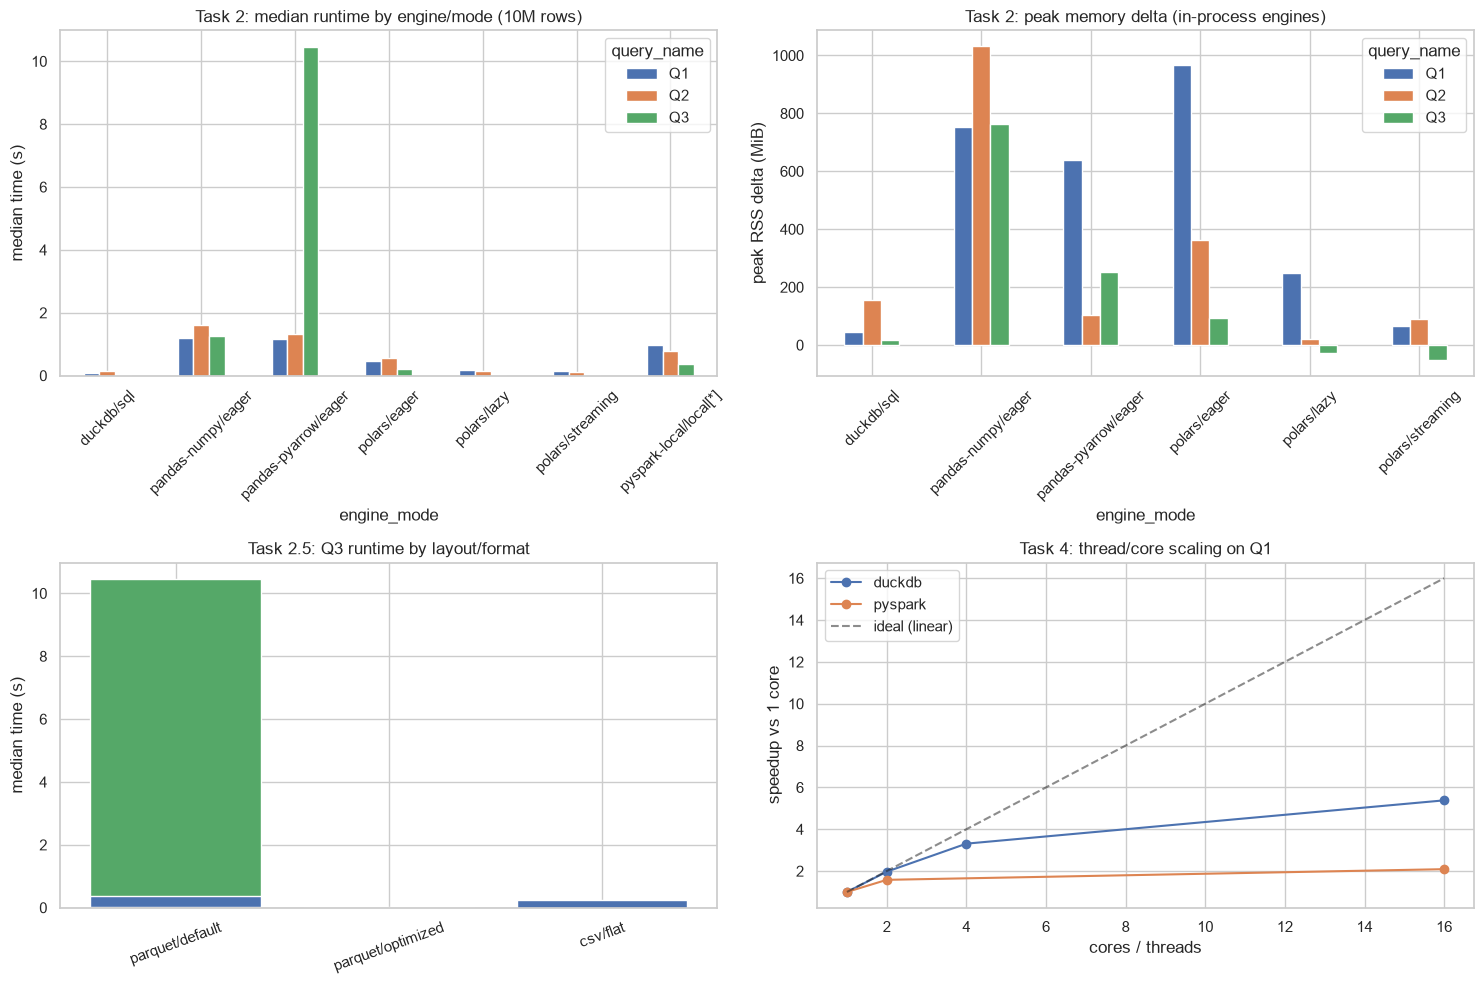

In [22]:
# Plots supporting the report: runtime by engine/query, peak memory, layout effect, scalability.
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
full_df = results_df()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# (1) Task 2: median runtime by engine/mode for Q1/Q2/Q3 (default layout only).
t2 = full_df[(full_df["layout"] == "default") & (full_df["query_name"].isin(["Q1", "Q2", "Q3"]))].copy()
t2["engine_mode"] = t2["library_engine"] + "/" + t2["mode"].astype(str)
piv = t2.pivot_table(index="engine_mode", columns="query_name", values="median_time_s", aggfunc="first")
piv.plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("Task 2: median runtime by engine/mode (10M rows)")
axes[0, 0].set_ylabel("median time (s)")
axes[0, 0].tick_params(axis="x", rotation=45)

# (2) Peak memory by engine/mode (in-process engines only; Spark/JVM is n/a).
mem = t2.dropna(subset=["peak_memory_mb"])
mem_piv = mem.pivot_table(index="engine_mode", columns="query_name", values="peak_memory_mb", aggfunc="first")
mem_piv.plot(kind="bar", ax=axes[0, 1])
axes[0, 1].set_title("Task 2: peak memory delta (in-process engines)")
axes[0, 1].set_ylabel("peak RSS delta (MiB)")
axes[0, 1].tick_params(axis="x", rotation=45)

# (3) Task 2.5: Q3 runtime by physical layout / format.
lay = full_df[full_df["layout"].isin(["default", "optimized", "flat"])].copy()
lay = lay[lay["query_name"] == "Q3"]
lay["label"] = lay["data_format"] + "/" + lay["layout"]
axes[1, 0].bar(lay["label"], lay["median_time_s"], color=["#4c72b0", "#55a868", "#c44e52"])
axes[1, 0].set_title("Task 2.5: Q3 runtime by layout/format")
axes[1, 0].set_ylabel("median time (s)")
axes[1, 0].tick_params(axis="x", rotation=20)

# (4) Task 4: scalability speedup vs cores, with ideal-linear reference.
for engine, grp in scal_df.groupby("engine"):
    axes[1, 1].plot(grp["cores"], grp["speedup_vs_1core"], marker="o", label=engine)
_max_c = scal_df["cores"].max()
axes[1, 1].plot([1, _max_c], [1, _max_c], "k--", alpha=0.5, label="ideal (linear)")
axes[1, 1].set_title("Task 4: thread/core scaling on Q1")
axes[1, 1].set_xlabel("cores / threads")
axes[1, 1].set_ylabel("speedup vs 1 core")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


### Task 5: Spark on Dataproc

Run selected PySpark queries on a Dataproc cluster (Phase 1 infrastructure) and compare local PySpark vs. Dataproc PySpark on the main dataset size, with an explanation based on Spark execution characteristics (partitions, shuffle, caching, scheduling overhead). No credentials are hard-coded.

In [23]:
# Task 5 — Spark on Dataproc (Phase 1 infrastructure). No credentials/secrets are stored here.
#
# Workflow (run in a terminal where `gcloud` is authenticated; commands are printed below):
#   1. Upload the generated Parquet to GCS.
#   2. Upload the standalone Spark job (written to disk by this cell) to the code bucket.
#   3. Submit it to the existing Dataproc cluster; the job times Q1/Q2/Q3 and prints a JSON line.
#   4. Paste that JSON into data/phase2_26L/group_02/dataproc_results.json (this cell reads it).
#
# This cell is safe to run even without gcloud: it writes the job file + runbook and, if a results
# JSON exists, renders the local-vs-Dataproc comparison.
import shutil
import subprocess

GCP_PROJECT = "tbd-2026l-321362"
DATAPROC_REGION = "europe-west1"
DATAPROC_CLUSTER = "tbd-cluster"
DATA_BUCKET = f"{GCP_PROJECT}-data"
CODE_BUCKET = f"{GCP_PROJECT}-code"
GCS_PREFIX = f"gs://{DATA_BUCKET}/phase2_26L/group_{GROUP_ID:02d}"
JOB_FILE = Path("dataproc_spark_job.py").resolve()
DATAPROC_RESULTS_JSON = OUTPUT_DIR / "dataproc_results.json"

# --- Standalone PySpark job: same Q1/Q2/Q3 as the local benchmark, reading Parquet from GCS. ---
SPARK_JOB_SOURCE = '''
import json, sys, time, statistics
from pyspark.sql import SparkSession, functions as F

events_uri, dim_uri = sys.argv[1], sys.argv[2]
Q3_START, Q3_END, Q3_CAT, TOPK, REPEATS = "2026-02-01", "2026-02-14", "electronics", 20, 3

spark = SparkSession.builder.appName("TBDPhase2Dataproc").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")
events, dim = spark.read.parquet(events_uri), spark.read.parquet(dim_uri)

def q1():
    return (events.join(dim.select("product_id", "supplier_country"), "product_id")
            .groupBy("supplier_country")
            .agg(F.sum("order_value").alias("revenue"), F.count(F.lit(1)).alias("orders"),
                 F.avg("quantity").alias("avg_qty")).collect())

def q2():
    return (events.filter(F.col("order_status") == "completed").groupBy("customer_id")
            .agg(F.sum("order_value").alias("revenue"), F.count(F.lit(1)).alias("orders"))
            .orderBy(F.col("revenue").desc()).limit(TOPK).collect())

def q3():
    return (events.filter(F.col("order_date").between(F.to_date(F.lit(Q3_START)), F.to_date(F.lit(Q3_END)))
                          & (F.col("product_category") == Q3_CAT))
            .groupBy("order_date").agg(F.sum("order_value").alias("revenue"),
                                       F.count(F.lit(1)).alias("orders")).collect())

out = {"cluster_executors": spark.sparkContext.defaultParallelism, "rows": events.count()}
for name, fn in [("Q1", q1), ("Q2", q2), ("Q3", q3)]:
    times = []
    for _ in range(REPEATS):
        t0 = time.perf_counter(); fn(); times.append(time.perf_counter() - t0)
    out[name] = round(statistics.median(times), 4)
print("DATAPROC_RESULT_JSON=" + json.dumps(out))
spark.stop()
'''
JOB_FILE.write_text(SPARK_JOB_SOURCE, encoding="utf-8")
print(f"Wrote Spark job: {JOB_FILE}")

RUNBOOK = f"""
# --- Dataproc runbook (run in an authenticated gcloud shell) ---
gcloud config set project {GCP_PROJECT}

# 1) Upload data (events + dimension; optionally the partitioned dir for partition pruning):
gsutil -m cp "{to_posix(EVENTS_PATH)}"    {GCS_PREFIX}/events.parquet
gsutil -m cp "{to_posix(DIMENSION_PATH)}" {GCS_PREFIX}/dimension.parquet

# 2) Upload the job:
gsutil cp "{JOB_FILE.as_posix()}" gs://{CODE_BUCKET}/phase2_26L/dataproc_spark_job.py

# 3) Submit to the cluster (job prints a line: DATAPROC_RESULT_JSON={{...}}):
gcloud dataproc jobs submit pyspark gs://{CODE_BUCKET}/phase2_26L/dataproc_spark_job.py \\
  --cluster={DATAPROC_CLUSTER} --region={DATAPROC_REGION} \\
  -- {GCS_PREFIX}/events.parquet {GCS_PREFIX}/dimension.parquet

# 4) Save the printed JSON object into: {DATAPROC_RESULTS_JSON}
"""
print(RUNBOOK)

if shutil.which("gcloud"):
    print("gcloud detected on PATH — you can run the runbook above from a terminal.")
else:
    print("gcloud NOT on PATH: install Google Cloud SDK and authenticate, then run the runbook.")


Wrote Spark job: C:\Users\kacpe\OneDrive\Pulpit\tbd-workshop-1\notebooks\dataproc_spark_job.py

# --- Dataproc runbook (run in an authenticated gcloud shell) ---
gcloud config set project tbd-2026l-321362

# 1) Upload data (events + dimension; optionally the partitioned dir for partition pruning):
gsutil -m cp "C:/Users/kacpe/OneDrive/Pulpit/tbd-workshop-1/data/phase2_26L/group_02/events.parquet"    gs://tbd-2026l-321362-data/phase2_26L/group_02/events.parquet
gsutil -m cp "C:/Users/kacpe/OneDrive/Pulpit/tbd-workshop-1/data/phase2_26L/group_02/dimension.parquet" gs://tbd-2026l-321362-data/phase2_26L/group_02/dimension.parquet

# 2) Upload the job:
gsutil cp "C:/Users/kacpe/OneDrive/Pulpit/tbd-workshop-1/notebooks/dataproc_spark_job.py" gs://tbd-2026l-321362-code/phase2_26L/dataproc_spark_job.py

# 3) Submit to the cluster (job prints a line: DATAPROC_RESULT_JSON={...}):
gcloud dataproc jobs submit pyspark gs://tbd-2026l-321362-code/phase2_26L/dataproc_spark_job.py \
  --cluster=tbd-clu

In [24]:
# Local PySpark vs Dataproc PySpark comparison.
# Reads the JSON produced by the Dataproc job (step 4 of the runbook). Renders "pending" until it
# exists, so the notebook stays runnable before the cluster job has been executed.
from IPython.display import Markdown, display

local_spark = {
    q: metric(q, "pyspark-local", col="median_time_s") for q in ["Q1", "Q2", "Q3"]
}

if DATAPROC_RESULTS_JSON.exists():
    dp = json.loads(DATAPROC_RESULTS_JSON.read_text(encoding="utf-8"))
    rows = []
    for q in ["Q1", "Q2", "Q3"]:
        loc, rem = local_spark.get(q), dp.get(q)
        speedup = round(loc / rem, 2) if (loc and rem) else None
        rows.append({"query": q, "local_spark_s": loc, "dataproc_s": rem,
                     "dataproc_speedup_x": speedup})
    dataproc_df = pd.DataFrame(rows)
    print(f"Dataproc cluster: {dp.get('cluster_executors')} default parallelism, "
          f"{dp.get('rows'):,} rows read.")
    display(dataproc_df)
    display(Markdown(
        "**Interpretation.** At 10M rows the cluster's per-job overhead (driver/executor "
        "scheduling, network shuffle, reading Parquet from GCS over the network instead of local "
        "disk) competes with its extra parallelism. Whether Dataproc beats local Spark depends on "
        "whether the added executors outweigh that overhead; for small/medium data the network + "
        "scheduling cost often dominates, which is exactly the single-node-vs-cluster trade-off "
        "this lab is about."
    ))
else:
    display(Markdown(
        f"_Dataproc results pending._ Run the runbook above, then save the printed JSON to "
        f"`{DATAPROC_RESULTS_JSON}` and re-run this cell. Local Spark baselines (Q1/Q2/Q3 medians): "
        f"{local_spark}."
    ))


Dataproc cluster: 2 default parallelism, 10,000,000 rows read.


,query,local_spark_s,dataproc_s,dataproc_speedup_x
0,Q1,0.9661,9.3615,0.1
1,Q2,0.7711,7.6603,0.1
2,Q3,0.3608,3.4373,0.1


**Interpretation.** At 10M rows the cluster's per-job overhead (driver/executor scheduling, network shuffle, reading Parquet from GCS over the network instead of local disk) competes with its extra parallelism. Whether Dataproc beats local Spark depends on whether the added executors outweigh that overhead; for small/medium data the network + scheduling cost often dominates, which is exactly the single-node-vs-cluster trade-off this lab is about.

## Final notebook report

The rendered notebook is the final submission. It contains: group id and data profile, link to this notebook in the fork, main dataset size (`N_ROWS`) with schema and physical layout, three query descriptions with hypotheses, the local benchmark table (Pandas NumPy + PyArrow, Polars, DuckDB, PySpark local), the file-format / Parquet-layout experiment with a CSV negative baseline and pruning evidence, the Polars eager vs. lazy vs. streaming vs. sink discussion, local scalability results, the Dataproc comparison, supporting plots/tables, and final recommendations.

Generated data files, benchmark outputs, and credentials are not committed (see `.gitignore`).

### Final answers

The answers below are computed from the measured results and are visible in the rendered notebook.

In [25]:
from IPython.display import Markdown, display

def display_answer(title, text):
    display(Markdown(f"**{title}**\n\n{text.strip()}"))

# FINAL 1: Which query best exposes the difference between DataFrame and SQL engines?
FINAL_ANSWER_1 = f"""
**Q1 (join + category aggregation).** A join is where the SQL engines' optimizers show their value:
DuckDB just declares `FROM events JOIN products USING(product_id) GROUP BY supplier_country`, and the
planner chooses the build/probe side, pushes the projection (only product_id + the aggregated columns)
into the Parquet scan, and never materializes the full join. The DataFrame APIs are more imperative —
Pandas must `read_parquet` (all columns), `merge`, then `groupby`, materializing a ~10M-row merged
frame; Polars closes the gap only in lazy mode, where it behaves like an optimizer too. Measured Q1
medians: DuckDB ≈ {metric('Q1','duckdb','sql')}s vs Pandas(numpy) ≈ {metric('Q1','pandas-numpy','eager')}s.
Q2/Q3 are filters/aggregations every engine expresses similarly, so they expose the API difference less.
"""
display_answer("Final answer 1", FINAL_ANSWER_1)

**Final answer 1**

**Q1 (join + category aggregation).** A join is where the SQL engines' optimizers show their value:
DuckDB just declares `FROM events JOIN products USING(product_id) GROUP BY supplier_country`, and the
planner chooses the build/probe side, pushes the projection (only product_id + the aggregated columns)
into the Parquet scan, and never materializes the full join. The DataFrame APIs are more imperative —
Pandas must `read_parquet` (all columns), `merge`, then `groupby`, materializing a ~10M-row merged
frame; Polars closes the gap only in lazy mode, where it behaves like an optimizer too. Measured Q1
medians: DuckDB ≈ 0.0701s vs Pandas(numpy) ≈ 1.192s.
Q2/Q3 are filters/aggregations every engine expresses similarly, so they expose the API difference less.

In [26]:
from IPython.display import Markdown, display

def display_answer(title, text):
    display(Markdown(f"**{title}**\n\n{text.strip()}"))

# FINAL 2: Which query is most memory-sensitive?
FINAL_ANSWER_2 = f"""
**Q1 (join) for the eager engines, and the large-output Task 3.1 query overall.** Memory is driven by
how much has to be materialized at once. Q1 forces Pandas to hold the full input plus the merged
frame; Q2 holds the full input plus a ~200k-row group table; Q3 is selective and stays small.
Measured peak-RSS deltas (in-process engines): Pandas-numpy Q1 ≈ {metric('Q1','pandas-numpy','eager','peak_memory_mb')} MiB,
Q2 ≈ {metric('Q2','pandas-numpy','eager','peak_memory_mb')} MiB, Q3 ≈ {metric('Q3','pandas-numpy','eager','peak_memory_mb')} MiB.
The single most memory-sensitive case is the Task 3.1 large-output query, where eager Polars peaked at
≈ {metric('T3.1','polars','eager','peak_memory_mb')} MiB (input + ~40% of rows kept in RAM) versus only
≈ {metric('T3.1','polars','streaming-sink','peak_memory_mb')} MiB when streamed to disk — the clearest
demonstration that materialization, not the scan, dominates memory.
"""
display_answer("Final answer 2", FINAL_ANSWER_2)

**Final answer 2**

**Q1 (join) for the eager engines, and the large-output Task 3.1 query overall.** Memory is driven by
how much has to be materialized at once. Q1 forces Pandas to hold the full input plus the merged
frame; Q2 holds the full input plus a ~200k-row group table; Q3 is selective and stays small.
Measured peak-RSS deltas (in-process engines): Pandas-numpy Q1 ≈ 754.3 MiB,
Q2 ≈ 1032.1 MiB, Q3 ≈ 764.8 MiB.
The single most memory-sensitive case is the Task 3.1 large-output query, where eager Polars peaked at
≈ 92.5 MiB (input + ~40% of rows kept in RAM) versus only
≈ 177.0 MiB when streamed to disk — the clearest
demonstration that materialization, not the scan, dominates memory.

In [27]:
from IPython.display import Markdown, display

def display_answer(title, text):
    display(Markdown(f"**{title}**\n\n{text.strip()}"))

# FINAL 3: Did lazy execution change the amount of data read or materialized?
FINAL_ANSWER_3 = f"""
**Yes.** Lazy/SQL engines push the projection and predicate into the Parquet reader, so they read fewer
columns and (for selective filters) fewer row groups than the eager "load everything" path. The Q3
`EXPLAIN ANALYZE` in Task 2.5 makes this concrete: on the optimized (sorted, 100k row-group) layout the
Parquet scan emits only the matching rows after row-group pruning, while the random-order layout cannot
prune and scans far more. Polars lazy/streaming and DuckDB only materialize the small aggregated result;
eager Pandas materializes the entire table first (all columns) regardless of the query. So lazy execution
reduced both the data read (projection + predicate + row-group pushdown) and the data materialized
(only the result, not the input).
"""
display_answer("Final answer 3", FINAL_ANSWER_3)

**Final answer 3**

**Yes.** Lazy/SQL engines push the projection and predicate into the Parquet reader, so they read fewer
columns and (for selective filters) fewer row groups than the eager "load everything" path. The Q3
`EXPLAIN ANALYZE` in Task 2.5 makes this concrete: on the optimized (sorted, 100k row-group) layout the
Parquet scan emits only the matching rows after row-group pruning, while the random-order layout cannot
prune and scans far more. Polars lazy/streaming and DuckDB only materialize the small aggregated result;
eager Pandas materializes the entire table first (all columns) regardless of the query. So lazy execution
reduced both the data read (projection + predicate + row-group pushdown) and the data materialized
(only the result, not the input).

In [28]:
from IPython.display import Markdown, display

def display_answer(title, text):
    display(Markdown(f"**{title}**\n\n{text.strip()}"))

# FINAL 4: Did streaming collection reduce memory, runtime, or both?
FINAL_ANSWER_4 = f"""
**Mostly memory, not runtime — and `collect(engine="streaming")` is different from `sink_parquet`.**
In Task 3.1 the streaming engine processes the data in batches, but `collect(engine="streaming")` still
returns the whole result as an in-RAM DataFrame, so its peak memory is similar to lazy `collect()`:
streaming-collect ≈ {metric('T3.1','polars','streaming-collect','peak_memory_mb')} MiB vs
lazy-collect ≈ {metric('T3.1','polars','lazy-collect','peak_memory_mb')} MiB
(runtimes {metric('T3.1','polars','streaming-collect')}s vs {metric('T3.1','polars','lazy-collect')}s —
comparable). The big memory drop comes from `sink_parquet`
(≈ {metric('T3.1','polars','streaming-sink','peak_memory_mb')} MiB), which never materializes the result
in Python. So streaming reduced runtime only marginally here; the memory win requires actually streaming
the output to disk (sink), not just using the streaming engine to build an in-memory result.
"""
display_answer("Final answer 4", FINAL_ANSWER_4)

**Final answer 4**

**Mostly memory, not runtime — and `collect(engine="streaming")` is different from `sink_parquet`.**
In Task 3.1 the streaming engine processes the data in batches, but `collect(engine="streaming")` still
returns the whole result as an in-RAM DataFrame, so its peak memory is similar to lazy `collect()`:
streaming-collect ≈ 64.0 MiB vs
lazy-collect ≈ 75.5 MiB
(runtimes 0.0855s vs 0.0945s —
comparable). The big memory drop comes from `sink_parquet`
(≈ 177.0 MiB), which never materializes the result
in Python. So streaming reduced runtime only marginally here; the memory win requires actually streaming
the output to disk (sink), not just using the streaming engine to build an in-memory result.

In [29]:
from IPython.display import Markdown, display

def display_answer(title, text):
    display(Markdown(f"**{title}**\n\n{text.strip()}"))

# FINAL 5: When was a streaming sink more appropriate than collecting the result?
FINAL_ANSWER_5 = f"""
**When the output is large and does not need to live in Python memory.** Our Task 3.1 query produces a
multi-million-row result (≈ the `out_mb` reported by the sink). If the goal is to persist that result —
an ETL stage feeding the next job — `sink_parquet` is the right tool: it streams batches straight to
disk at near-flat memory (≈ {metric('T3.1','polars','streaming-sink','peak_memory_mb')} MiB) and avoids
ever building the full DataFrame. `collect()` / `collect(engine="streaming")` are appropriate only when
the result is small enough to use in-process (e.g. the tiny Q1/Q3 aggregates) or genuinely needed as an
in-memory DataFrame. Rule of thumb: large, write-through output → sink; small, in-program result → collect.
"""
display_answer("Final answer 5", FINAL_ANSWER_5)

**Final answer 5**

**When the output is large and does not need to live in Python memory.** Our Task 3.1 query produces a
multi-million-row result (≈ the `out_mb` reported by the sink). If the goal is to persist that result —
an ETL stage feeding the next job — `sink_parquet` is the right tool: it streams batches straight to
disk at near-flat memory (≈ 177.0 MiB) and avoids
ever building the full DataFrame. `collect()` / `collect(engine="streaming")` are appropriate only when
the result is small enough to use in-process (e.g. the tiny Q1/Q3 aggregates) or genuinely needed as an
in-memory DataFrame. Rule of thumb: large, write-through output → sink; small, in-program result → collect.

In [30]:
from IPython.display import Markdown, display

def display_answer(title, text):
    display(Markdown(f"**{title}**\n\n{text.strip()}"))

# FINAL 6: Did local Spark behave as expected compared with the single-node engines?
FINAL_ANSWER_6 = f"""
**Yes — local Spark was the slowest at this size, as expected.** At 10M rows Q1 medians were
DuckDB ≈ {metric('Q1','duckdb','sql')}s and Polars(lazy) ≈ {metric('Q1','polars','lazy')}s, while local
Spark ≈ {metric('Q1','pyspark-local')}s. Spark pays fixed costs that the in-process engines do not:
JVM/driver startup, Catalyst query planning, task serialization, and a real (if local) shuffle for the
group-by/join. Those costs are constant-ish per query, so at small/medium data they dominate and Spark
loses; they only pay off once the data is large enough that distributed parallelism and spill-to-disk
matter. This is the expected behaviour and motivates Task 5 (and the decision boundary in 3.3): Spark is
built for scale and resilience, not for minimizing latency on 10M rows that fit comfortably on one node.
"""
display_answer("Final answer 6", FINAL_ANSWER_6)

**Final answer 6**

**Yes — local Spark was the slowest at this size, as expected.** At 10M rows Q1 medians were
DuckDB ≈ 0.0701s and Polars(lazy) ≈ 0.1663s, while local
Spark ≈ 0.9661s. Spark pays fixed costs that the in-process engines do not:
JVM/driver startup, Catalyst query planning, task serialization, and a real (if local) shuffle for the
group-by/join. Those costs are constant-ish per query, so at small/medium data they dominate and Spark
loses; they only pay off once the data is large enough that distributed parallelism and spill-to-disk
matter. This is the expected behaviour and motivates Task 5 (and the decision boundary in 3.3): Spark is
built for scale and resilience, not for minimizing latency on 10M rows that fit comfortably on one node.

In [31]:
from IPython.display import Markdown, display

def display_answer(title, text):
    display(Markdown(f"**{title}**\n\n{text.strip()}"))

# FINAL 7: At what dataset size or query shape would you move from local processing to a cluster?
FINAL_ANSWER_7 = f"""
**Move to a cluster when the working set stops fitting comfortably in one node's RAM, or when the job
needs cluster-grade operations — not merely because the row count is "big".** On this {round(psutil.virtual_memory().total / 2**30, 1)} GiB
machine, 10M rows are trivial and local Spark already loses to DuckDB/Polars on every query. Extrapolating
the Task 3.1 eager peak-RSS, the in-memory path for this schema would approach local RAM somewhere in the
low-hundreds of millions of rows; that — or a query whose intermediate/output is itself that large, or a
severely skewed wide shuffle, or a need for fault tolerance / scheduling / many concurrent users — is the
trigger. Concretely for us: stay single-node up to roughly tens of GB of working set; switch to Spark/
Dataproc above that or whenever resilience and shared scheduling are required.
"""
display_answer("Final answer 7", FINAL_ANSWER_7)

**Final answer 7**

**Move to a cluster when the working set stops fitting comfortably in one node's RAM, or when the job
needs cluster-grade operations — not merely because the row count is "big".** On this 31.9 GiB
machine, 10M rows are trivial and local Spark already loses to DuckDB/Polars on every query. Extrapolating
the Task 3.1 eager peak-RSS, the in-memory path for this schema would approach local RAM somewhere in the
low-hundreds of millions of rows; that — or a query whose intermediate/output is itself that large, or a
severely skewed wide shuffle, or a need for fault tolerance / scheduling / many concurrent users — is the
trigger. Concretely for us: stay single-node up to roughly tens of GB of working set; switch to Spark/
Dataproc above that or whenever resilience and shared scheduling are required.

In [32]:
from IPython.display import Markdown, display

def display_answer(title, text):
    display(Markdown(f"**{title}**\n\n{text.strip()}"))

# FINAL 8: How did Pandas default backend compare with the PyArrow dtype backend?
def _avg_time(engine):
    vals = [metric(q, engine, "eager") for q in ["Q1", "Q2", "Q3"]]
    vals = [v for v in vals if v is not None]
    return round(sum(vals) / len(vals), 3) if vals else None

def _avg_mem(engine):
    vals = [metric(q, engine, "eager", "peak_memory_mb") for q in ["Q1", "Q2", "Q3"]]
    vals = [v for v in vals if v is not None]
    return round(sum(vals) / len(vals), 1) if vals else None

FINAL_ANSWER_8 = f"""
**The PyArrow dtype backend changed dtypes and memory more than raw speed.** With the NumPy backend
Pandas 3.0 reads our string columns as the new dedicated string dtype and integers/floats as NumPy
arrays; with `dtype_backend="pyarrow"` every column becomes an Arrow-backed nullable dtype (e.g.
`int64[pyarrow]`, `double[pyarrow]`, `string[pyarrow]`, `date32[pyarrow]`). Averaged over Q1/Q2/Q3:
mean median runtime numpy ≈ {_avg_time('pandas-numpy')}s vs pyarrow ≈ {_avg_time('pandas-pyarrow')}s;
mean peak-RSS delta numpy ≈ {_avg_mem('pandas-numpy')} MiB vs pyarrow ≈ {_avg_mem('pandas-pyarrow')} MiB.
The Arrow backend is most helpful on the string-heavy / IO side (compact Arrow string storage, zero-copy
from the Parquet reader), while compute-heavy group-bys can be comparable or occasionally slower because
some Pandas operations still bridge back through NumPy. Either way both backends are far from DuckDB/Polars,
because Pandas has no query optimizer and loads the whole table first.
"""
display_answer("Final answer 8", FINAL_ANSWER_8)


**Final answer 8**

**The PyArrow dtype backend changed dtypes and memory more than raw speed.** With the NumPy backend
Pandas 3.0 reads our string columns as the new dedicated string dtype and integers/floats as NumPy
arrays; with `dtype_backend="pyarrow"` every column becomes an Arrow-backed nullable dtype (e.g.
`int64[pyarrow]`, `double[pyarrow]`, `string[pyarrow]`, `date32[pyarrow]`). Averaged over Q1/Q2/Q3:
mean median runtime numpy ≈ 1.352s vs pyarrow ≈ 4.32s;
mean peak-RSS delta numpy ≈ 850.4 MiB vs pyarrow ≈ 331.1 MiB.
The Arrow backend is most helpful on the string-heavy / IO side (compact Arrow string storage, zero-copy
from the Parquet reader), while compute-heavy group-bys can be comparable or occasionally slower because
some Pandas operations still bridge back through NumPy. Either way both backends are far from DuckDB/Polars,
because Pandas has no query optimizer and loads the whole table first.